# Tophat Scan Experiments

This notebook runs several scans for the half-SLM tophat optimizer:

1. Scan the loss-scale exponent `d` in `C = 10^d (1 - F)^2` and plot accepted-iteration fidelity histories.
2. Scan independent initialization curvatures `R_x` and `R_y` in `R_x x^2 + R_y y^2`.
3. Fix the tophat aspect ratio to 5:1 and scan target size versus lens focal length.
4. Use an ideal Gaussian input beam, then scan Gaussian radius versus target size at fixed 300 mm focal length.
5. Compare different objective-function forms using `M = F`.
6. Scan single-parameter `R` and `sigma`, then plot final `F` and efficiency heatmaps.
7. Scan several initialization and target parameters, then plot final `F` versus efficiency.

The fidelity used by the CG loss is the coherent field fidelity inside the mask:

```text
F = |I_tilde^dagger T_tilde|^2
  = |sum_pq sqrt(I_tilde_pq T_tilde_pq) exp(i(Phi_pq - phi_pq))|^2
```

Here `I_tilde` and `T_tilde` are the normalized output and target intensities inside the mask. With `optimize_phase=False`, the same expression is evaluated without the phase factor. Therefore `F` is bounded between 0 and 1, and `1 - F` is non-negative.

Here `d` is only the exponent in the cost prefactor `10^d`. It is scanned only in experiment 1. The later experiments use the fixed `base_loss_exponent`.


## 1. Imports and Parameters


In [ ]:
from __future__ import annotations

from pathlib import Path
from time import perf_counter
from typing import Any

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import numpy.typing as npt
import scipy.optimize
import torch

import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "examples" else Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from slm_tophat_beam_shaping.initial_holograms import axis_curvature_hologram, curvature_hologram
from slm_tophat_beam_shaping.loss_functions import build_circular_mask
from slm_tophat_beam_shaping.optimizer import CGOptimizer
from slm_tophat_beam_shaping.optical_planes import CameraPlane, SLMPlane
from slm_tophat_beam_shaping.propagator import Propagator
from slm_tophat_beam_shaping.target_profiles import apply_psf_smoothing, build_rectangle_target

scan_output_dir = PROJECT_ROOT / "tophat_scan_outputs"
scan_output_dir.mkdir(parents=True, exist_ok=True)

# Native SLM and compute grid.
full_slm_shape: tuple[int, int] = (1080, 1920)
superpixel_size: int = 4
slm_shape: tuple[int, int] = (full_slm_shape[0] // superpixel_size, full_slm_shape[1] // superpixel_size)
half_slm_shape: tuple[int, int] = (slm_shape[0], slm_shape[1] // 2)
padding_factor: int = 2
half_camera_shape: tuple[int, int] = (half_slm_shape[0] * padding_factor, half_slm_shape[1] * padding_factor)

# Optical and calibration settings.
wavelength_nm: float = 420.0
calibration_h5_path: Path = PROJECT_ROOT / "420_wavefront_superpixel_00006.h5"
half_side: str = "left"
slm_pixel_pitch_um: float = 8.0
camera_pixel_pitch_um: float = 3.45
focal_length_mm: float = 200.0
slmsuite_camera_shape: tuple[int, int] = full_slm_shape
slmsuite_wavefront_r2_threshold: float = 0.5
slmsuite_remove_background: bool = True
slmsuite_apply_calibration: bool = True
slmsuite_amplitude_key: str = "amplitude"
slmsuite_phase_key: str = "phase"

# Base target and mask settings.
base_target_width_x_um: float = 40.0
base_target_height_y_um: float = 212.0
base_psf_sigma_um: float = 20.0
base_mask_radius_margin_um: float = 100.0

# Base hologram initialization settings.
base_linear_tilt: float = 0.0
base_astigmatism_weight: float = 0.0
base_quadratic_curvature: float = 1.72e-3
base_quadratic_curvature_x: float = 3.0 * base_quadratic_curvature * base_astigmatism_weight
base_quadratic_curvature_y: float = 3.0 * base_quadratic_curvature * (1.0 - base_astigmatism_weight)
base_linear_angle_rad: float = np.pi / 4.0
base_conical_weight: float = 0.0

# CG settings. Keep scan_maxiter modest first; increase after checking runtime.
scan_maxiter: int = 200
base_loss_exponent: float = 12.0
loss_scale: float = 10.0 ** base_loss_exponent
optimize_phase: bool = True

# Experiment 1: d is the exponent in C = 10^d (1 - F)^2.
scan_loss_exponents: tuple[float, ...] = (1.0, 2.0, 3.0, 4.0, 5.0, 6.0,7.0)
plot_one_minus_fidelity: bool = True

# Experiment 2: scan independent quadratic curvatures in R_x x^2 + R_y y^2.
scan_quadratic_curvature_x_values: tuple[float, ...] = (0.0, 0.5e-3, 1.0e-3, 1.5e-3, 2.0e-3)
scan_quadratic_curvature_y_values: tuple[float, ...] = (2.0e-3, 3.5e-3, 5.0e-3, 6.5e-3, 8.0e-3)

# Experiment 3: fixed-aspect tophat size versus focal length.
aspect_ratio_scan_y_over_x: float = 5.0
scan_aspect_short_axis_um_values: tuple[float, ...] = (20.0, 30.0, 40.0, 50.0, 60.0)
scan_focal_length_mm_values: tuple[float, ...] = (100.0, 150.0, 200.0, 250.0, 300.0)

# Experiment 4: ideal Gaussian input beam radius, target size, and focal length.
ideal_gaussian_focal_length_mm: float = 300.0
scan_ideal_gaussian_focal_length_mm_values: tuple[float, ...] = (100.0, 150.0, 200.0, 250.0, 300.0)
scan_ideal_gaussian_radius_um_values: tuple[float, ...] = np.linspace(0.5, 3, 21) * 1e3
scan_ideal_gaussian_short_axis_um_values: tuple[float, ...] = np.linspace(20, 50, 21)
ideal_gaussian_contour_metric: str = "efficiency"
ideal_gaussian_contour_level: float = 0.34

# Experiment 5: compare objective functions using M = F.
loss_form_scan_scale: float = loss_scale
loss_form_names: tuple[str, ...] = ("linear", "quadratic", "quartic", "log", "exp")
loss_form_labels: dict[str, str] = {
    "linear": "1 - M",
    "quadratic": "(1 - M)^2",
    "quartic": "(1 - M)^4",
    "log": "log(1 - M)",
    "exp": "exp(1 - M)",
}

# Experiment 6: R-sigma grid.
scan_quadratic_curvature_values: tuple[float, ...] = (0.2e-3, 0.8e-3, 2.4e-3, 4.0e-3, 5.6e-3, 7.2e-3)
scan_psf_sigma_um_values: tuple[float, ...] = (20.0, 25.0, 30.0, 35.0, 40.0, 45.0, 50.0)

# Experiment 7: broad parameter scan.
wide_target_sizes_um: tuple[tuple[float, float], ...] = ((30.0, 180.0), (40.0, 212.0), (50.0, 250.0))
wide_psf_sigma_um_values: tuple[float, ...] = (10.0, 20.0, 30.0)
wide_quadratic_curvature_values: tuple[float, ...] = (1.2e-3, 1.72e-3, 2.4e-3)
wide_linear_tilt_values: tuple[float, ...] = (-0.04, 0.0, 0.04)
wide_conical_weight_values: tuple[float, ...] = (0.0,)


## 2. Load slmsuite Input Beam


/opt/anaconda3/envs/machine_learning_torch/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda3/envs/machine_learning_torch/lib/python3.11/site-packages/slmsuite/holography/algorithms/_header.py:30: UserWarning: cupy is not installed; using numpy. Install cupy for faster GPU-based holography.
  warnings.warn(
/opt/anaconda3/envs/machine_learning_torch/lib/python3.11/site-packages/slmsuite/hardware/cameras/camera.py:444: UserWarning: 'camera' _get_image_hw() failed 5 times before quitting.
  warnings.warn(f"'{self.name}' _get_image_hw() failed {failures} times before quitting.")
/opt/anaconda3/envs/machine_learning_torch/lib/python3.11/site-packages/slmsuite/hardware/cameraslms.py:456: UserWarning: You are using slmsuite 0.4.0, but the calibration in '420_wavefront_superpixel_00006.h5' was crea

Full compute SLM shape: (270, 480)
Half SLM shape: (270, 240)
Half camera shape: (540, 480)
Input amplitude shape: (270, 240)


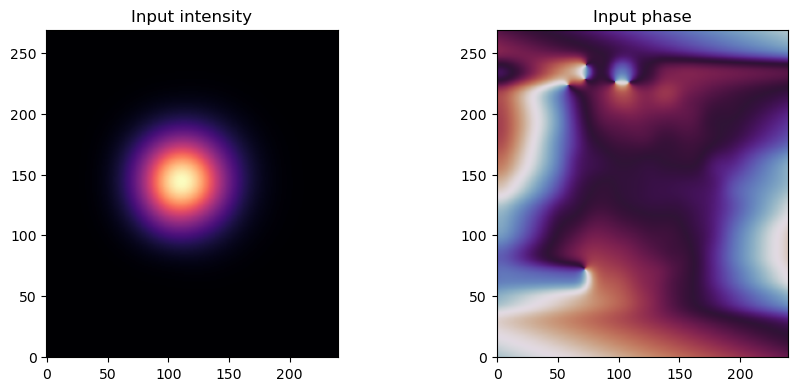

In [3]:
def downsample_by_superpixel(data: npt.ArrayLike, superpixel_size_value: int) -> npt.NDArray[np.float64]:
    data_array = np.asarray(data, dtype=float)
    if data_array.ndim != 2:
        raise ValueError(f"data must be 2D, got shape {data_array.shape}.")
    if data_array.shape[0] % superpixel_size_value != 0 or data_array.shape[1] % superpixel_size_value != 0:
        raise ValueError(
            "data shape must be divisible by superpixel_size, "
            f"got data_shape={data_array.shape}, superpixel_size={superpixel_size_value}."
        )
    ny = data_array.shape[0] // superpixel_size_value
    nx = data_array.shape[1] // superpixel_size_value
    return data_array.reshape(ny, superpixel_size_value, nx, superpixel_size_value).mean(axis=(1, 3))


def downsample_phase_by_superpixel(phase: npt.ArrayLike, superpixel_size_value: int) -> npt.NDArray[np.float64]:
    phase_array = np.asarray(phase, dtype=float)
    if phase_array.ndim != 2:
        raise ValueError(f"phase must be 2D, got shape {phase_array.shape}.")
    real_part = downsample_by_superpixel(np.cos(phase_array), superpixel_size_value)
    imag_part = downsample_by_superpixel(np.sin(phase_array), superpixel_size_value)
    return np.angle(real_part + 1j * imag_part)


def require_calibration_array(calibration_results: dict[str, Any], key: str, expected_shape: tuple[int, int]) -> npt.NDArray[np.float64]:
    if key not in calibration_results:
        available_keys = sorted(str(item) for item in calibration_results.keys())
        raise KeyError(f"Calibration result key {key!r} was not found. Available keys: {available_keys}.")
    array = np.asarray(calibration_results[key], dtype=float)
    if array.shape != expected_shape:
        raise ValueError(f"Calibration result {key!r} shape must be {expected_shape}, got {array.shape}.")
    if not np.all(np.isfinite(array)):
        raise ValueError(f"Calibration result {key!r} contains NaN or infinite values.")
    return array


def load_slmsuite_input_beam_and_phase(
    calibration_path: str,
    full_shape: tuple[int, int],
    superpixel_size_value: int,
    slm_pitch_um: float,
    wavelength_value_nm: float,
    camera_shape: tuple[int, int],
    r2_threshold: float,
    remove_background: bool,
    apply_calibration: bool,
    amplitude_key: str,
    phase_key: str,
) -> tuple[npt.NDArray[np.float64], npt.NDArray[np.float64], dict[str, Any]]:
    from slmsuite.hardware.cameras.simulated import SimulatedCamera
    from slmsuite.hardware.cameraslms import FourierSLM
    from slmsuite.hardware.slms.simulated import SimulatedSLM

    slm_size_xy = (int(full_shape[1]), int(full_shape[0]))
    camera_size_xy = (int(camera_shape[1]), int(camera_shape[0]))
    slm = SimulatedSLM(slm_size_xy, pitch_um=(slm_pitch_um, slm_pitch_um), wav_um=wavelength_value_nm / 1000.0)
    camera = SimulatedCamera(slm, resolution=camera_size_xy)
    fourier_slm = FourierSLM(camera, slm)
    fourier_slm.load_calibration("wavefront_superpixel", file_path=calibration_path)
    calibration_results = fourier_slm.wavefront_calibration_superpixel_process(
        plot=False,
        r2_threshold=r2_threshold,
        remove_background=remove_background,
        apply=apply_calibration,
    )
    amplitude_full = require_calibration_array(calibration_results, amplitude_key, full_shape)
    phase_full = require_calibration_array(calibration_results, phase_key, full_shape)
    amplitude = downsample_by_superpixel(np.clip(amplitude_full, 0.0, None), superpixel_size_value)
    phase = downsample_phase_by_superpixel(phase_full, superpixel_size_value)
    if np.max(amplitude) <= 0:
        raise ValueError("Loaded slmsuite amplitude contains no positive values after downsampling.")
    return amplitude / np.max(amplitude), np.mod(phase, 2.0 * np.pi), calibration_results


def crop_half_slm(
    amplitude: npt.ArrayLike,
    phase: npt.ArrayLike,
    side: str,
    expected_shape: tuple[int, int],
) -> tuple[npt.NDArray[np.float64], npt.NDArray[np.float64]]:
    if side not in ("left", "right"):
        raise ValueError(f"side must be 'left' or 'right', got {side}.")
    amplitude_array = np.asarray(amplitude, dtype=float)
    phase_array = np.asarray(phase, dtype=float)
    if amplitude_array.shape != expected_shape or phase_array.shape != expected_shape:
        raise ValueError(
            f"amplitude and phase must both have shape {expected_shape}, "
            f"got {amplitude_array.shape} and {phase_array.shape}."
        )
    split_index = expected_shape[1] // 2
    if side == "left":
        amplitude_half = amplitude_array[:, :split_index]
        phase_half = phase_array[:, :split_index]
    else:
        amplitude_half = amplitude_array[:, split_index:]
        phase_half = phase_array[:, split_index:]
    if np.max(amplitude_half) <= 0:
        raise ValueError(f"{side} half input amplitude contains no positive values.")
    return amplitude_half / np.max(amplitude_half), phase_half.copy()


full_input_amplitude, full_input_phase, calibration_results = load_slmsuite_input_beam_and_phase(
    calibration_h5_path,
    full_slm_shape,
    superpixel_size,
    slm_pixel_pitch_um,
    wavelength_nm,
    slmsuite_camera_shape,
    slmsuite_wavefront_r2_threshold,
    slmsuite_remove_background,
    slmsuite_apply_calibration,
    slmsuite_amplitude_key,
    slmsuite_phase_key,
)
input_amplitude, input_phase = crop_half_slm(full_input_amplitude, full_input_phase, half_side, slm_shape)

print("Full compute SLM shape:", slm_shape)
print("Half SLM shape:", half_slm_shape)
print("Half camera shape:", half_camera_shape)
print("Input amplitude shape:", input_amplitude.shape)

fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.8), constrained_layout=True)
axes[0].imshow(input_amplitude**2, origin="lower", cmap="magma", aspect="equal")
axes[0].set_title("Input intensity")
axes[1].imshow(input_phase, origin="lower", cmap="twilight", aspect="equal")
axes[1].set_title("Input phase")
plt.show()


## 3. Optimizer and Metric Helpers


In [4]:
def cost_overlap_fidelity(
    output_field: npt.ArrayLike,
    target_amplitude: npt.ArrayLike,
    target_phase: npt.ArrayLike,
    target_mask: npt.ArrayLike,
) -> float:
    output_array = np.asarray(output_field, dtype=np.complex128)
    target_array = np.asarray(target_amplitude, dtype=float)
    phase_array = np.asarray(target_phase, dtype=float)
    mask = np.asarray(target_mask, dtype=float)
    if output_array.shape != target_array.shape or output_array.shape != phase_array.shape or output_array.shape != mask.shape:
        raise ValueError(
            "output_field, target_amplitude, target_phase, and target_mask must have matching shapes, "
            f"got {output_array.shape}, {target_array.shape}, {phase_array.shape}, and {mask.shape}."
        )
    target_field = target_array * mask * np.exp(1j * phase_array)
    output_weighted_field = output_array * mask
    numerator = float(np.abs(np.sum(np.conj(target_field) * output_weighted_field)) ** 2)
    denominator = float(np.sum(np.abs(target_field) ** 2) * np.sum(np.abs(output_weighted_field) ** 2))
    if denominator <= 0.0:
        raise ValueError("Cannot compute cost-overlap fidelity because the denominator is zero.")
    return numerator / denominator


def intensity_shape_fidelity(
    output_field: npt.ArrayLike,
    target_amplitude: npt.ArrayLike,
    target_mask: npt.ArrayLike,
) -> float:
    output_intensity = np.abs(np.asarray(output_field, dtype=np.complex128)) ** 2
    target_intensity = np.asarray(target_amplitude, dtype=float) ** 2
    mask = np.asarray(target_mask, dtype=float)
    if output_intensity.shape != target_intensity.shape or output_intensity.shape != mask.shape:
        raise ValueError(
            "output_field, target_amplitude, and target_mask must have matching shapes, "
            f"got {output_intensity.shape}, {target_intensity.shape}, and {mask.shape}."
        )
    output_weighted = output_intensity * mask
    target_weighted = target_intensity * mask
    numerator = float(np.sum(output_weighted * target_weighted)) ** 2
    denominator = float(np.sum(output_weighted**2) * np.sum(target_weighted**2))
    if denominator <= 0.0:
        raise ValueError("Cannot compute intensity shape fidelity because the denominator is zero.")
    return numerator / denominator


def output_field_from_hologram(optimizer: CGOptimizer, hologram: npt.ArrayLike) -> npt.NDArray[np.complex128]:
    hologram_array = np.asarray(hologram, dtype=float).reshape(optimizer.propagator.slm_plane.shape)
    slm_shape_local = optimizer.propagator.slm_plane.shape
    padding_shape_local = optimizer.propagator.padding_farfield.shape
    slm_field = optimizer.propagator.slm_plane.amplitude * np.exp(
        1j * (optimizer.propagator.slm_plane.phase + hologram_array)
    )
    padded_field = np.zeros(padding_shape_local, dtype=np.complex128)
    y0 = (padding_shape_local[0] - slm_shape_local[0]) // 2
    x0 = (padding_shape_local[1] - slm_shape_local[1]) // 2
    padded_field[y0:y0 + slm_shape_local[0], x0:x0 + slm_shape_local[1]] = slm_field / padding_shape_local[1]
    return np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(padded_field)))


def build_scan_optimizer_from_initial_hologram(
    width_x_um: float,
    height_y_um: float,
    psf_sigma_um: float,
    mask_radius_margin_um: float,
    initial_hologram: npt.ArrayLike,
) -> CGOptimizer:
    initial_hologram_array = np.asarray(initial_hologram, dtype=float)
    slm = SLMPlane(
        half_slm_shape,
        wavelength_nm,
        slm_pixel_pitch_um,
        superpixel_size,
        input_amplitude,
        input_phase,
        initial_hologram_array,
    )
    camera = CameraPlane(
        half_camera_shape,
        wavelength_nm,
        (1.0, 1.0),
        camera_pixel_pitch_um,
        np.zeros(half_camera_shape),
        np.zeros(half_camera_shape),
    )
    propagator = Propagator(slm, camera, focal_length_mm, padding_factor)
    ideal_target = build_rectangle_target(
        half_camera_shape,
        propagator.camera_plane.x_axis_um,
        propagator.camera_plane.y_axis_um,
        width_x_um,
        height_y_um,
    )
    target_amplitude = apply_psf_smoothing(ideal_target, psf_sigma_um, psf_sigma_um, propagator.camera_plane.scale_um)
    target_phase = np.zeros_like(target_amplitude)
    mask_center_x_um = 0.5 * (propagator.camera_plane.x_axis_um[0] + propagator.camera_plane.x_axis_um[-1])
    mask_center_y_um = 0.5 * (propagator.camera_plane.y_axis_um[0] + propagator.camera_plane.y_axis_um[-1])
    mask_radius_um = max(width_x_um, height_y_um) / 2.0 + mask_radius_margin_um
    target_mask = build_circular_mask(
        half_camera_shape,
        propagator.camera_plane.x_axis_um,
        propagator.camera_plane.y_axis_um,
        mask_center_x_um,
        mask_center_y_um,
        mask_radius_um,
    )
    target_plane = CameraPlane(
        half_camera_shape,
        wavelength_nm,
        propagator.camera_plane.scale_um,
        camera_pixel_pitch_um,
        target_amplitude,
        target_phase,
    )
    optimizer = CGOptimizer(propagator, target_plane, target_mask)
    optimizer.set_initial_hologram_array(initial_hologram_array)
    return optimizer


def build_scan_optimizer(
    width_x_um: float,
    height_y_um: float,
    psf_sigma_um: float,
    mask_radius_margin_um: float,
    linear_tilt: float,
    astigmatism_weight: float,
    quadratic_curvature: float,
    linear_angle_rad: float,
    conical_weight: float,
) -> CGOptimizer:
    initial_hologram = curvature_hologram(
        shape=half_slm_shape,
        linear_tilt=linear_tilt,
        astigmatism_weight=astigmatism_weight,
        quadratic_curvature=quadratic_curvature,
        linear_angle_rad=linear_angle_rad,
        conical_weight=conical_weight,
        center=(half_slm_shape[0] / 2.0, half_slm_shape[1] / 2.0),
    )
    return build_scan_optimizer_from_initial_hologram(
        width_x_um,
        height_y_um,
        psf_sigma_um,
        mask_radius_margin_um,
        initial_hologram,
    )


def build_axis_curvature_scan_optimizer(
    width_x_um: float,
    height_y_um: float,
    psf_sigma_um: float,
    mask_radius_margin_um: float,
    linear_tilt: float,
    quadratic_curvature_x: float,
    quadratic_curvature_y: float,
    linear_angle_rad: float,
    conical_weight: float,
) -> CGOptimizer:
    initial_hologram = axis_curvature_hologram(
        shape=half_slm_shape,
        linear_tilt=linear_tilt,
        quadratic_curvature_x=quadratic_curvature_x,
        quadratic_curvature_y=quadratic_curvature_y,
        linear_angle_rad=linear_angle_rad,
        conical_weight=conical_weight,
        center=(half_slm_shape[0] / 2.0, half_slm_shape[1] / 2.0),
    )
    return build_scan_optimizer_from_initial_hologram(
        width_x_um,
        height_y_um,
        psf_sigma_um,
        mask_radius_margin_um,
        initial_hologram,
    )

def optimize_with_cost_overlap_history(
    optimizer: CGOptimizer,
    maxiter_value: int,
    loss_scale_value: float,
    optimize_phase_value: bool,
) -> tuple[list[float], Any]:
    if optimizer.initial_hologram is None:
        raise RuntimeError("Initial hologram is not set.")
    target_amplitude, target_phase, target_mask = optimizer._require_optimization_target()
    optimizer.loss_history = []
    optimizer.iteration_loss_history = []
    optimizer._last_loss = None
    optimizer._loss_scale = float(loss_scale_value)
    optimizer._optimize_phase = bool(optimize_phase_value)
    optimizer._torch_cache = optimizer._build_torch_cache(target_amplitude, target_phase, target_mask)
    fidelity_history: list[float] = []
    iteration_fidelity_history: list[float] = []
    iteration_elapsed_seconds: list[float] = []

    def objective(hologram_1d: npt.NDArray[np.float64]) -> tuple[float, npt.NDArray[np.float64]]:
        loss_value, gradient = optimizer.compute_loss_and_gradient(hologram_1d)
        optimizer.loss_history.append(loss_value)
        optimizer._last_loss = loss_value
        output_field = output_field_from_hologram(optimizer, hologram_1d)
        fidelity_history.append(cost_overlap_fidelity(output_field, target_amplitude, target_phase, target_mask))
        return loss_value, gradient

    start_time = perf_counter()

    def callback(hologram_1d: npt.NDArray[np.float64]) -> None:
        if optimizer._last_loss is None:
            raise RuntimeError("Optimizer callback was called before any loss evaluation.")
        optimizer.iteration_loss_history.append(optimizer._last_loss)
        output_field = output_field_from_hologram(optimizer, hologram_1d)
        iteration_fidelity_history.append(cost_overlap_fidelity(output_field, target_amplitude, target_phase, target_mask))
        iteration_elapsed_seconds.append(perf_counter() - start_time)

    result = scipy.optimize.minimize(
        objective,
        optimizer.initial_hologram.reshape(-1),
        method="CG",
        jac=True,
        callback=callback,
        options={"maxiter": int(maxiter_value), "disp": False},
    )
    optimizer.optimization_time_sec = perf_counter() - start_time
    optimizer.optimization_result = result
    optimizer.final_hologram = np.mod(result.x.reshape(optimizer.propagator.slm_plane.shape), 2.0 * np.pi)
    optimizer.propagator.slm_plane.set_hologram(optimizer.final_hologram)
    optimizer.propagator.propagate("sft")
    optimizer.cost_overlap_evaluation_history = np.asarray(fidelity_history, dtype=float)
    optimizer.cost_overlap_iteration_history = np.asarray(iteration_fidelity_history, dtype=float)
    optimizer.iteration_elapsed_seconds = np.asarray(iteration_elapsed_seconds, dtype=float)
    del optimizer._torch_cache
    return fidelity_history, result



def compute_loss_gradient_overlap_for_loss_form(
    optimizer: CGOptimizer,
    hologram_1d: npt.NDArray[np.float64],
    loss_scale_value: float,
    loss_form: str,
) -> tuple[float, npt.NDArray[np.float64], float]:
    if not hasattr(optimizer, "_torch_cache"):
        target_amplitude, target_phase, target_mask = optimizer._require_optimization_target()
        optimizer._torch_cache = optimizer._build_torch_cache(target_amplitude, target_phase, target_mask)
    cache = optimizer._torch_cache
    dtype = cache["dtype"]
    device = cache["device"]
    slm_shape_local = optimizer.propagator.slm_plane.shape
    padding_shape_local = optimizer.propagator.padding_farfield.shape
    hologram_flat = torch.tensor(hologram_1d, dtype=dtype, device=device, requires_grad=True)
    hologram = hologram_flat.view(slm_shape_local)
    slm_field = cache["slm_amplitude"] * torch.exp(1j * (cache["slm_phase"] + hologram))
    padded_field = torch.zeros(padding_shape_local, dtype=torch.complex128, device=device)
    y0 = (padding_shape_local[0] - slm_shape_local[0]) // 2
    x0 = (padding_shape_local[1] - slm_shape_local[1]) // 2
    padded_field[y0:y0 + slm_shape_local[0], x0:x0 + slm_shape_local[1]] = cache["a0"] * slm_field
    output_field = torch.fft.fftshift(torch.fft.fft2(torch.fft.ifftshift(padded_field)))
    target_field = cache["target_amplitude"] * cache["target_mask"] * torch.exp(1j * cache["target_phase"])
    output_weighted_field = output_field * cache["target_mask"]
    numerator = torch.abs(torch.sum(torch.conj(target_field) * output_weighted_field)) ** 2
    denominator = torch.sum(torch.abs(target_field) ** 2) * torch.sum(torch.abs(output_weighted_field) ** 2)
    overlap = numerator / torch.clamp(denominator, min=torch.finfo(dtype).eps)
    gap = 1.0 - overlap
    gap_safe = torch.clamp(gap, min=torch.finfo(dtype).eps)
    scale = torch.as_tensor(float(loss_scale_value), dtype=dtype, device=device)
    if loss_form == "linear":
        loss = scale * gap
    elif loss_form == "quadratic":
        loss = scale * gap**2
    elif loss_form == "quartic":
        loss = scale * gap**4
    elif loss_form == "log":
        loss = scale * torch.log(gap_safe)
    elif loss_form == "exp":
        loss = scale * torch.exp(gap)
    else:
        raise ValueError(f"Unsupported loss_form {loss_form!r}.")
    loss.backward()
    if hologram_flat.grad is None:
        raise RuntimeError("Torch did not produce a hologram gradient for the custom CG objective.")
    return float(loss.detach().cpu()), hologram_flat.grad.detach().cpu().numpy().reshape(-1), float(overlap.detach().cpu())


def optimize_with_loss_form_history(
    optimizer: CGOptimizer,
    maxiter_value: int,
    loss_scale_value: float,
    optimize_phase_value: bool,
    loss_form: str,
) -> tuple[list[float], Any]:
    if not optimize_phase_value:
        raise ValueError("loss-form scan is defined for the coherent field fidelity, so optimize_phase_value must be True.")
    if optimizer.initial_hologram is None:
        raise RuntimeError("Initial hologram is not set.")
    target_amplitude, target_phase, target_mask = optimizer._require_optimization_target()
    optimizer.loss_history = []
    optimizer.iteration_loss_history = []
    optimizer._last_loss = None
    optimizer._torch_cache = optimizer._build_torch_cache(target_amplitude, target_phase, target_mask)
    fidelity_history: list[float] = []

    def objective(hologram_1d: npt.NDArray[np.float64]) -> tuple[float, npt.NDArray[np.float64]]:
        loss_value, gradient, overlap = compute_loss_gradient_overlap_for_loss_form(
            optimizer,
            hologram_1d,
            loss_scale_value,
            loss_form,
        )
        optimizer.loss_history.append(loss_value)
        optimizer._last_loss = loss_value
        fidelity_history.append(overlap)
        return loss_value, gradient

    def callback(_hologram_1d: npt.NDArray[np.float64]) -> None:
        if optimizer._last_loss is None:
            raise RuntimeError("Optimizer callback was called before any loss evaluation.")
        optimizer.iteration_loss_history.append(optimizer._last_loss)

    start_time = perf_counter()
    result = scipy.optimize.minimize(
        objective,
        optimizer.initial_hologram.reshape(-1),
        method="CG",
        jac=True,
        callback=callback,
        options={"maxiter": int(maxiter_value), "disp": False},
    )
    optimizer.optimization_time_sec = perf_counter() - start_time
    optimizer.optimization_result = result
    optimizer.final_hologram = np.mod(result.x.reshape(optimizer.propagator.slm_plane.shape), 2.0 * np.pi)
    optimizer.propagator.slm_plane.set_hologram(optimizer.final_hologram)
    optimizer.propagator.propagate("sft")
    del optimizer._torch_cache
    return fidelity_history, result


def save_curve_arrays(
    output_prefix: str,
    curve_names: tuple[str, ...],
    fidelity_histories: list[npt.NDArray[np.float64]],
    summary_array: npt.NDArray[np.float64],
) -> None:
    max_length = max((history.size for history in fidelity_histories), default=0)
    evaluation_index = np.full((len(fidelity_histories), max_length), np.nan, dtype=float)
    fidelity_array = np.full_like(evaluation_index, np.nan)
    one_minus_array = np.full_like(evaluation_index, np.nan)
    for row, history in enumerate(fidelity_histories):
        length = history.size
        evaluation_index[row, :length] = np.arange(1, length + 1, dtype=float)
        fidelity_array[row, :length] = history
        one_minus_array[row, :length] = np.maximum(1.0 - history, np.finfo(float).eps)
    np.save(scan_output_dir / f"{output_prefix}_curve_names.npy", np.asarray(curve_names, dtype=str))
    np.save(scan_output_dir / f"{output_prefix}_evaluation_index.npy", evaluation_index)
    np.save(scan_output_dir / f"{output_prefix}_fidelity.npy", fidelity_array)
    np.save(scan_output_dir / f"{output_prefix}_one_minus_fidelity.npy", one_minus_array)
    np.save(scan_output_dir / f"{output_prefix}_summary.npy", summary_array)


def failed_scan_record(parameters: dict[str, Any], error: Exception) -> dict[str, Any]:
    record = dict(parameters)
    record.setdefault("loss_exponent", base_loss_exponent)
    record.setdefault("loss_scale", loss_scale)
    record.setdefault("accepted_iterations", 0)
    record.setdefault("loss_evaluations", 0)
    record.setdefault("cost_overlap_fidelity", np.nan)
    record.setdefault("intensity_shape_fidelity", np.nan)
    record.setdefault("field_fidelity_squared", np.nan)
    record.setdefault("efficiency", np.nan)
    record.setdefault("rms_error", np.nan)
    record.setdefault("phase_error", np.nan)
    record.setdefault("optimization_time_sec", np.nan)
    record["success"] = False
    record["message"] = f"{type(error).__name__}: {error}"
    return record


def print_scan_failure(label: str, error: Exception) -> None:
    print(f"Skipping {label}: {type(error).__name__}: {error}")




def build_axis_curvature_scan_optimizer_with_focal_length(
    width_x_um: float,
    height_y_um: float,
    psf_sigma_um: float,
    mask_radius_margin_um: float,
    linear_tilt: float,
    quadratic_curvature_x: float,
    quadratic_curvature_y: float,
    linear_angle_rad: float,
    conical_weight: float,
    focal_length_mm_value: float,
) -> CGOptimizer:
    initial_hologram = axis_curvature_hologram(
        shape=half_slm_shape,
        linear_tilt=linear_tilt,
        quadratic_curvature_x=quadratic_curvature_x,
        quadratic_curvature_y=quadratic_curvature_y,
        linear_angle_rad=linear_angle_rad,
        conical_weight=conical_weight,
        center=(half_slm_shape[0] / 2.0, half_slm_shape[1] / 2.0),
    )
    slm = SLMPlane(
        half_slm_shape,
        wavelength_nm,
        slm_pixel_pitch_um,
        superpixel_size,
        input_amplitude,
        input_phase,
        initial_hologram,
    )
    camera = CameraPlane(
        half_camera_shape,
        wavelength_nm,
        (1.0, 1.0),
        camera_pixel_pitch_um,
        np.zeros(half_camera_shape),
        np.zeros(half_camera_shape),
    )
    propagator = Propagator(slm, camera, float(focal_length_mm_value), padding_factor)
    ideal_target = build_rectangle_target(
        half_camera_shape,
        propagator.camera_plane.x_axis_um,
        propagator.camera_plane.y_axis_um,
        width_x_um,
        height_y_um,
    )
    target_amplitude = apply_psf_smoothing(ideal_target, psf_sigma_um, psf_sigma_um, propagator.camera_plane.scale_um)
    target_phase = np.zeros_like(target_amplitude)
    mask_center_x_um = 0.5 * (propagator.camera_plane.x_axis_um[0] + propagator.camera_plane.x_axis_um[-1])
    mask_center_y_um = 0.5 * (propagator.camera_plane.y_axis_um[0] + propagator.camera_plane.y_axis_um[-1])
    mask_radius_um = max(width_x_um, height_y_um) / 2.0 + mask_radius_margin_um
    target_mask = build_circular_mask(
        half_camera_shape,
        propagator.camera_plane.x_axis_um,
        propagator.camera_plane.y_axis_um,
        mask_center_x_um,
        mask_center_y_um,
        mask_radius_um,
    )
    target_plane = CameraPlane(
        half_camera_shape,
        wavelength_nm,
        propagator.camera_plane.scale_um,
        camera_pixel_pitch_um,
        target_amplitude,
        target_phase,
    )
    optimizer = CGOptimizer(propagator, target_plane, target_mask)
    optimizer.set_initial_hologram_array(initial_hologram)
    return optimizer


def run_aspect_ratio_focal_scan_case(
    short_axis_um: float,
    aspect_ratio_y_over_x: float,
    focal_length_mm_value: float,
    psf_sigma_um: float,
    mask_radius_margin_um: float,
    linear_tilt: float,
    quadratic_curvature_x: float,
    quadratic_curvature_y: float,
    linear_angle_rad: float,
    conical_weight: float,
    maxiter_value: int,
) -> dict[str, Any]:
    width_x_um = float(short_axis_um)
    height_y_um = float(short_axis_um) * float(aspect_ratio_y_over_x)
    optimizer = build_axis_curvature_scan_optimizer_with_focal_length(
        width_x_um,
        height_y_um,
        psf_sigma_um,
        mask_radius_margin_um,
        linear_tilt,
        quadratic_curvature_x,
        quadratic_curvature_y,
        linear_angle_rad,
        conical_weight,
        focal_length_mm_value,
    )
    optimizer.optimize(maxiter=maxiter_value, loss_scale=loss_scale, optimize_phase=optimize_phase)
    result = optimizer.get_result_summary()
    target_amplitude, target_phase, target_mask = optimizer._require_optimization_target()
    output_field = optimizer.propagator.padding_farfield.get_field()
    final_cost_overlap = cost_overlap_fidelity(output_field, target_amplitude, target_phase, target_mask)
    final_intensity_shape_fidelity = intensity_shape_fidelity(output_field, target_amplitude, target_mask)
    scipy_result = optimizer.optimization_result
    return {
        "short_axis_um": width_x_um,
        "aspect_ratio_y_over_x": aspect_ratio_y_over_x,
        "width_x_um": width_x_um,
        "height_y_um": height_y_um,
        "focal_length_mm": focal_length_mm_value,
        "psf_sigma_um": psf_sigma_um,
        "mask_radius_margin_um": mask_radius_margin_um,
        "linear_tilt": linear_tilt,
        "quadratic_curvature_x": quadratic_curvature_x,
        "quadratic_curvature_y": quadratic_curvature_y,
        "linear_angle_rad": linear_angle_rad,
        "conical_weight": conical_weight,
        "loss_exponent": base_loss_exponent,
        "loss_scale": loss_scale,
        "accepted_iterations": len(result.iteration_loss_history),
        "loss_evaluations": len(result.loss_history),
        "cost_overlap_fidelity": final_cost_overlap,
        "intensity_shape_fidelity": final_intensity_shape_fidelity,
        "field_fidelity_squared": result.fidelity,
        "efficiency": result.efficiency,
        "rms_error": result.rms_error,
        "phase_error": result.phase_error,
        "optimization_time_sec": result.optimization_time_sec,
        "success": bool(scipy_result.success) if scipy_result is not None else False,
        "message": str(scipy_result.message) if scipy_result is not None else "no scipy result",
    }


def build_perfect_gaussian_input_beam(
    shape: tuple[int, int],
    slm_pixel_pitch_um_value: float,
    superpixel_size_value: int,
    gaussian_radius_um: float,
) -> tuple[npt.NDArray[np.float64], npt.NDArray[np.float64]]:
    if gaussian_radius_um <= 0.0:
        raise ValueError(f"gaussian_radius_um must be positive, got {gaussian_radius_um}.")
    effective_pixel_um = float(slm_pixel_pitch_um_value) * int(superpixel_size_value)
    y_um = (np.arange(shape[0], dtype=float) - shape[0] / 2.0) * effective_pixel_um
    x_um = (np.arange(shape[1], dtype=float) - shape[1] / 2.0) * effective_pixel_um
    x_grid_um, y_grid_um = np.meshgrid(x_um, y_um, indexing="xy")
    amplitude = np.exp(-((x_grid_um / float(gaussian_radius_um)) ** 2 + (y_grid_um / float(gaussian_radius_um)) ** 2))
    phase = np.zeros(shape, dtype=float)
    return amplitude, phase


def build_axis_curvature_scan_optimizer_with_input_beam(
    width_x_um: float,
    height_y_um: float,
    psf_sigma_um: float,
    mask_radius_margin_um: float,
    linear_tilt: float,
    quadratic_curvature_x: float,
    quadratic_curvature_y: float,
    linear_angle_rad: float,
    conical_weight: float,
    focal_length_mm_value: float,
    input_amplitude_value: npt.ArrayLike,
    input_phase_value: npt.ArrayLike,
) -> CGOptimizer:
    initial_hologram = axis_curvature_hologram(
        shape=half_slm_shape,
        linear_tilt=linear_tilt,
        quadratic_curvature_x=quadratic_curvature_x,
        quadratic_curvature_y=quadratic_curvature_y,
        linear_angle_rad=linear_angle_rad,
        conical_weight=conical_weight,
        center=(half_slm_shape[0] / 2.0, half_slm_shape[1] / 2.0),
    )
    slm = SLMPlane(
        half_slm_shape,
        wavelength_nm,
        slm_pixel_pitch_um,
        superpixel_size,
        np.asarray(input_amplitude_value, dtype=float),
        np.asarray(input_phase_value, dtype=float),
        initial_hologram,
    )
    camera = CameraPlane(
        half_camera_shape,
        wavelength_nm,
        (1.0, 1.0),
        camera_pixel_pitch_um,
        np.zeros(half_camera_shape),
        np.zeros(half_camera_shape),
    )
    propagator = Propagator(slm, camera, float(focal_length_mm_value), padding_factor)
    ideal_target = build_rectangle_target(
        half_camera_shape,
        propagator.camera_plane.x_axis_um,
        propagator.camera_plane.y_axis_um,
        width_x_um,
        height_y_um,
    )
    target_amplitude = apply_psf_smoothing(ideal_target, psf_sigma_um, psf_sigma_um, propagator.camera_plane.scale_um)
    target_phase = np.zeros_like(target_amplitude)
    mask_center_x_um = 0.5 * (propagator.camera_plane.x_axis_um[0] + propagator.camera_plane.x_axis_um[-1])
    mask_center_y_um = 0.5 * (propagator.camera_plane.y_axis_um[0] + propagator.camera_plane.y_axis_um[-1])
    mask_radius_um = max(width_x_um, height_y_um) / 2.0 + mask_radius_margin_um
    target_mask = build_circular_mask(
        half_camera_shape,
        propagator.camera_plane.x_axis_um,
        propagator.camera_plane.y_axis_um,
        mask_center_x_um,
        mask_center_y_um,
        mask_radius_um,
    )
    target_plane = CameraPlane(
        half_camera_shape,
        wavelength_nm,
        propagator.camera_plane.scale_um,
        camera_pixel_pitch_um,
        target_amplitude,
        target_phase,
    )
    optimizer = CGOptimizer(propagator, target_plane, target_mask)
    optimizer.set_initial_hologram_array(initial_hologram)
    return optimizer


def run_ideal_gaussian_radius_size_scan_case(
    gaussian_radius_um: float,
    short_axis_um: float,
    aspect_ratio_y_over_x: float,
    focal_length_mm_value: float,
    psf_sigma_um: float,
    mask_radius_margin_um: float,
    linear_tilt: float,
    quadratic_curvature_x: float,
    quadratic_curvature_y: float,
    linear_angle_rad: float,
    conical_weight: float,
    maxiter_value: int,
) -> dict[str, Any]:
    gaussian_amplitude, gaussian_phase = build_perfect_gaussian_input_beam(
        half_slm_shape,
        slm_pixel_pitch_um,
        superpixel_size,
        gaussian_radius_um,
    )
    width_x_um = float(short_axis_um)
    height_y_um = float(short_axis_um) * float(aspect_ratio_y_over_x)
    optimizer = build_axis_curvature_scan_optimizer_with_input_beam(
        width_x_um,
        height_y_um,
        psf_sigma_um,
        mask_radius_margin_um,
        linear_tilt,
        quadratic_curvature_x,
        quadratic_curvature_y,
        linear_angle_rad,
        conical_weight,
        focal_length_mm_value,
        gaussian_amplitude,
        gaussian_phase,
    )
    optimizer.optimize(maxiter=maxiter_value, loss_scale=loss_scale, optimize_phase=optimize_phase)
    result = optimizer.get_result_summary()
    target_amplitude, target_phase, target_mask = optimizer._require_optimization_target()
    output_field = optimizer.propagator.padding_farfield.get_field()
    final_cost_overlap = cost_overlap_fidelity(output_field, target_amplitude, target_phase, target_mask)
    final_intensity_shape_fidelity = intensity_shape_fidelity(output_field, target_amplitude, target_mask)
    scipy_result = optimizer.optimization_result
    return {
        "gaussian_radius_um": gaussian_radius_um,
        "radius_definition": "amplitude 1/e radius in the SLM plane",
        "short_axis_um": width_x_um,
        "aspect_ratio_y_over_x": aspect_ratio_y_over_x,
        "width_x_um": width_x_um,
        "height_y_um": height_y_um,
        "focal_length_mm": focal_length_mm_value,
        "psf_sigma_um": psf_sigma_um,
        "mask_radius_margin_um": mask_radius_margin_um,
        "linear_tilt": linear_tilt,
        "quadratic_curvature_x": quadratic_curvature_x,
        "quadratic_curvature_y": quadratic_curvature_y,
        "linear_angle_rad": linear_angle_rad,
        "conical_weight": conical_weight,
        "loss_exponent": base_loss_exponent,
        "loss_scale": loss_scale,
        "accepted_iterations": len(result.iteration_loss_history),
        "loss_evaluations": len(result.loss_history),
        "cost_overlap_fidelity": final_cost_overlap,
        "intensity_shape_fidelity": final_intensity_shape_fidelity,
        "field_fidelity_squared": result.fidelity,
        "efficiency": result.efficiency,
        "rms_error": result.rms_error,
        "phase_error": result.phase_error,
        "optimization_time_sec": result.optimization_time_sec,
        "success": bool(scipy_result.success) if scipy_result is not None else False,
        "message": str(scipy_result.message) if scipy_result is not None else "no scipy result",
    }


def run_axis_curvature_scan_case(
    width_x_um: float,
    height_y_um: float,
    psf_sigma_um: float,
    mask_radius_margin_um: float,
    linear_tilt: float,
    quadratic_curvature_x: float,
    quadratic_curvature_y: float,
    linear_angle_rad: float,
    conical_weight: float,
    maxiter_value: int,
    record_history: bool,
) -> dict[str, Any]:
    optimizer = build_axis_curvature_scan_optimizer(
        width_x_um,
        height_y_um,
        psf_sigma_um,
        mask_radius_margin_um,
        linear_tilt,
        quadratic_curvature_x,
        quadratic_curvature_y,
        linear_angle_rad,
        conical_weight,
    )
    if record_history:
        fidelity_history, scipy_result = optimize_with_cost_overlap_history(optimizer, maxiter_value, loss_scale, optimize_phase)
    else:
        optimizer.optimize(maxiter=maxiter_value, loss_scale=loss_scale, optimize_phase=optimize_phase)
        fidelity_history = []
        scipy_result = optimizer.optimization_result
    result = optimizer.get_result_summary()
    target_amplitude, target_phase, target_mask = optimizer._require_optimization_target()
    output_field = optimizer.propagator.padding_farfield.get_field()
    final_cost_overlap = cost_overlap_fidelity(output_field, target_amplitude, target_phase, target_mask)
    final_intensity_shape_fidelity = intensity_shape_fidelity(output_field, target_amplitude, target_mask)
    return {
        "width_x_um": width_x_um,
        "height_y_um": height_y_um,
        "psf_sigma_um": psf_sigma_um,
        "mask_radius_margin_um": mask_radius_margin_um,
        "linear_tilt": linear_tilt,
        "quadratic_curvature_x": quadratic_curvature_x,
        "quadratic_curvature_y": quadratic_curvature_y,
        "linear_angle_rad": linear_angle_rad,
        "conical_weight": conical_weight,
        "loss_exponent": base_loss_exponent,
        "loss_scale": loss_scale,
        "accepted_iterations": len(result.iteration_loss_history),
        "loss_evaluations": len(result.loss_history),
        "cost_overlap_fidelity": final_cost_overlap,
        "intensity_shape_fidelity": final_intensity_shape_fidelity,
        "field_fidelity_squared": result.fidelity,
        "efficiency": result.efficiency,
        "rms_error": result.rms_error,
        "phase_error": result.phase_error,
        "optimization_time_sec": result.optimization_time_sec,
        "fidelity_history": np.asarray(fidelity_history, dtype=float),
        "success": bool(scipy_result.success) if scipy_result is not None else False,
        "message": str(scipy_result.message) if scipy_result is not None else "no scipy result",
    }


def run_scan_case(
    width_x_um: float,
    height_y_um: float,
    psf_sigma_um: float,
    mask_radius_margin_um: float,
    linear_tilt: float,
    astigmatism_weight: float,
    quadratic_curvature: float,
    linear_angle_rad: float,
    conical_weight: float,
    maxiter_value: int,
    record_history: bool,
) -> dict[str, Any]:
    optimizer = build_scan_optimizer(
        width_x_um,
        height_y_um,
        psf_sigma_um,
        mask_radius_margin_um,
        linear_tilt,
        astigmatism_weight,
        quadratic_curvature,
        linear_angle_rad,
        conical_weight,
    )
    if record_history:
        fidelity_history, scipy_result = optimize_with_cost_overlap_history(optimizer, maxiter_value, loss_scale, optimize_phase)
    else:
        optimizer.optimize(maxiter=maxiter_value, loss_scale=loss_scale, optimize_phase=optimize_phase)
        fidelity_history = []
        scipy_result = optimizer.optimization_result
    result = optimizer.get_result_summary()
    target_amplitude, target_phase, target_mask = optimizer._require_optimization_target()
    output_field = optimizer.propagator.padding_farfield.get_field()
    final_cost_overlap = cost_overlap_fidelity(output_field, target_amplitude, target_phase, target_mask)
    final_intensity_shape_fidelity = intensity_shape_fidelity(output_field, target_amplitude, target_mask)
    return {
        "width_x_um": width_x_um,
        "height_y_um": height_y_um,
        "psf_sigma_um": psf_sigma_um,
        "mask_radius_margin_um": mask_radius_margin_um,
        "linear_tilt": linear_tilt,
        "astigmatism_weight": astigmatism_weight,
        "quadratic_curvature": quadratic_curvature,
        "linear_angle_rad": linear_angle_rad,
        "conical_weight": conical_weight,
        "loss_exponent": base_loss_exponent,
        "loss_scale": loss_scale,
        "accepted_iterations": len(result.iteration_loss_history),
        "loss_evaluations": len(result.loss_history),
        "cost_overlap_fidelity": final_cost_overlap,
        "intensity_shape_fidelity": final_intensity_shape_fidelity,
        "field_fidelity_squared": result.fidelity,
        "efficiency": result.efficiency,
        "rms_error": result.rms_error,
        "phase_error": result.phase_error,
        "optimization_time_sec": result.optimization_time_sec,
        "fidelity_history": np.asarray(fidelity_history, dtype=float),
        "success": bool(scipy_result.success) if scipy_result is not None else False,
        "message": str(scipy_result.message) if scipy_result is not None else "no scipy result",
    }


def save_scan_table(path: Path, records: list[dict[str, Any]]) -> None:
    scalar_keys = [
        "width_x_um",
        "height_y_um",
        "psf_sigma_um",
        "mask_radius_margin_um",
        "linear_tilt",
        "astigmatism_weight",
        "quadratic_curvature",
        "linear_angle_rad",
        "conical_weight",
        "loss_exponent",
        "loss_scale",
        "accepted_iterations",
        "loss_evaluations",
        "cost_overlap_fidelity",
        "intensity_shape_fidelity",
        "field_fidelity_squared",
        "efficiency",
        "rms_error",
        "phase_error",
        "optimization_time_sec",
        "success",
    ]
    with path.open("w", encoding="utf-8") as file:
        file.write(",".join(scalar_keys) + "\n")
        for record in records:
            file.write(",".join(str(record[key]) for key in scalar_keys) + "\n")


## 4. Scan Loss-Scale Exponent d: Fidelity vs Iteration


Running loss-scale scan d=1.0, loss_scale=1.000e+01
Running loss-scale scan d=2.0, loss_scale=1.000e+02
Running loss-scale scan d=3.0, loss_scale=1.000e+03
Running loss-scale scan d=4.0, loss_scale=1.000e+04
Running loss-scale scan d=5.0, loss_scale=1.000e+05
Running loss-scale scan d=6.0, loss_scale=1.000e+06
Running loss-scale scan d=7.0, loss_scale=1.000e+07


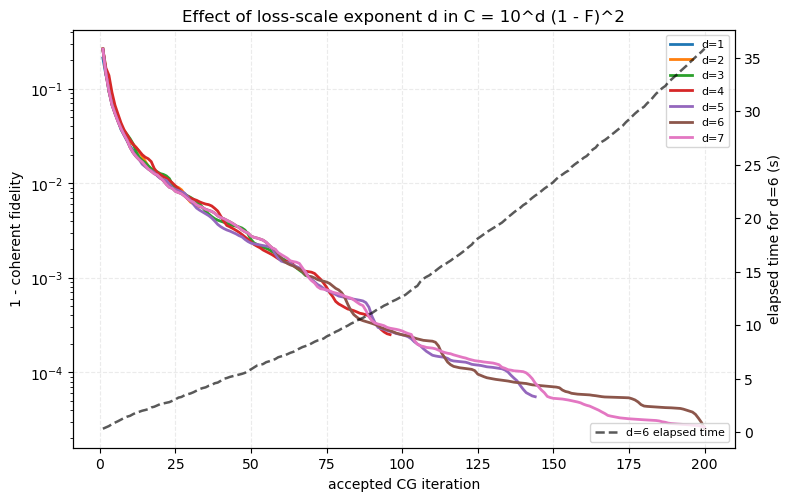

In [11]:
d_scan_records: list[dict[str, Any]] = []
d_scan_evaluation_histories: list[npt.NDArray[np.float64]] = []
d_scan_iteration_histories: list[npt.NDArray[np.float64]] = []
d_scan_iteration_time_histories: list[npt.NDArray[np.float64]] = []

fig, ax = plt.subplots(1, 1, figsize=(7.8, 4.9), constrained_layout=True)
ax_time = ax.twinx()
time_axis_drawn = False
for loss_exponent in scan_loss_exponents:
    case_loss_scale = 10.0 ** float(loss_exponent)
    label = f"loss-scale scan d={loss_exponent}, loss_scale={case_loss_scale:.3e}"
    print(f"Running {label}")
    try:
        optimizer = build_scan_optimizer(
            base_target_width_x_um,
            base_target_height_y_um,
            base_psf_sigma_um,
            base_mask_radius_margin_um,
            base_linear_tilt,
            base_astigmatism_weight,
            base_quadratic_curvature,
            base_linear_angle_rad,
            base_conical_weight,
        )
        fidelity_history, scipy_result = optimize_with_cost_overlap_history(
            optimizer,
            scan_maxiter,
            case_loss_scale,
            optimize_phase,
        )
        evaluation_history = np.asarray(fidelity_history, dtype=float)
        iteration_history = np.asarray(optimizer.cost_overlap_iteration_history, dtype=float)
        iteration_time_history = np.asarray(optimizer.iteration_elapsed_seconds, dtype=float)
        plot_history = iteration_history if iteration_history.size > 0 else evaluation_history
        final_fidelity = plot_history[-1] if plot_history.size > 0 else np.nan
        record = {
            "loss_exponent": float(loss_exponent),
            "loss_scale": case_loss_scale,
            "loss_evaluations": len(evaluation_history),
            "accepted_iterations": len(iteration_history),
            "final_cost_overlap_fidelity": final_fidelity,
            "optimization_time_sec": float(optimizer.optimization_time_sec),
            "success": bool(scipy_result.success),
            "message": str(scipy_result.message),
        }
        if plot_history.size > 0:
            y_values = np.maximum(1.0 - plot_history, np.finfo(float).eps) if plot_one_minus_fidelity else plot_history
            ax.plot(np.arange(1, len(y_values) + 1), y_values, lw=2.0, label=f"d={float(loss_exponent):.3g}")
        if np.isclose(float(loss_exponent), 6.0) and iteration_time_history.size > 0:
            ax_time.plot(
                np.arange(1, iteration_time_history.size + 1),
                iteration_time_history,
                color="black",
                lw=1.8,
                ls="--",
                alpha=0.65,
                label="d=6 elapsed time",
            )
            time_axis_drawn = True
    except Exception as error:
        print_scan_failure(label, error)
        evaluation_history = np.asarray([], dtype=float)
        iteration_history = np.asarray([], dtype=float)
        iteration_time_history = np.asarray([], dtype=float)
        record = failed_scan_record(
            {
                "loss_exponent": float(loss_exponent),
                "loss_scale": case_loss_scale,
                "final_cost_overlap_fidelity": np.nan,
            },
            error,
        )
    d_scan_evaluation_histories.append(evaluation_history)
    d_scan_iteration_histories.append(iteration_history)
    d_scan_iteration_time_histories.append(iteration_time_history)
    d_scan_records.append(record)

with (scan_output_dir / "loss_exponent_scan_summary.csv").open("w", encoding="utf-8") as file:
    file.write(
        "loss_exponent,loss_scale,loss_evaluations,accepted_iterations,"
        "final_cost_overlap_fidelity,optimization_time_sec,success,message\n"
    )
    for record in d_scan_records:
        file.write(
            f"{record['loss_exponent']},{record['loss_scale']},{record['loss_evaluations']},"
            f"{record['accepted_iterations']},{record['final_cost_overlap_fidelity']},"
            f"{record['optimization_time_sec']},{record['success']},{record['message']}\n"
        )

d_scan_summary_array = np.asarray(
    [
        [
            record["loss_exponent"],
            record["loss_scale"],
            record["loss_evaluations"],
            record["accepted_iterations"],
            record["final_cost_overlap_fidelity"],
            record["optimization_time_sec"],
            float(record["success"]),
        ]
        for record in d_scan_records
    ],
    dtype=float,
)
save_curve_arrays(
    "loss_exponent_scan_iteration",
    tuple(f"d={record['loss_exponent']:.6g}" for record in d_scan_records),
    d_scan_iteration_histories,
    d_scan_summary_array,
)

ax.set_xlabel("accepted CG iteration")
if plot_one_minus_fidelity:
    ax.set_ylabel("1 - coherent fidelity")
    ax.set_yscale("log")
else:
    ax.set_ylabel("coherent fidelity F")
    ax.set_ylim(0.0, 1.02)
ax_time.set_ylabel("elapsed time for d=6 (s)")
if time_axis_drawn:
    ax_time.legend(loc="lower right", frameon=True, fontsize=8)
ax.set_title("Effect of loss-scale exponent d in C = 10^d (1 - F)^2")
ax.grid(True, alpha=0.25, linestyle="--")
ax.legend(loc="upper right", frameon=True, fontsize=8)
fig.savefig(scan_output_dir / "loss_exponent_scan_fidelity_vs_iteration.png", dpi=220)
plt.show()


In [6]:
required_names = ("d_scan_records", "d_scan_evaluation_histories", "d_scan_iteration_histories", "d_scan_iteration_time_histories")
missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise RuntimeError(f"Run the loss-exponent scan first. Missing variables: {missing_names}.")

loss_exponent_scan_parameters = {
    "full_slm_shape": full_slm_shape,
    "superpixel_size": superpixel_size,
    "slm_shape": slm_shape,
    "half_slm_shape": half_slm_shape,
    "padding_factor": padding_factor,
    "half_camera_shape": half_camera_shape,
    "wavelength_nm": wavelength_nm,
    "calibration_h5_path": calibration_h5_path,
    "half_side": half_side,
    "slm_pixel_pitch_um": slm_pixel_pitch_um,
    "camera_pixel_pitch_um": camera_pixel_pitch_um,
    "focal_length_mm": focal_length_mm,
    "base_target_width_x_um": base_target_width_x_um,
    "base_target_height_y_um": base_target_height_y_um,
    "base_psf_sigma_um": base_psf_sigma_um,
    "base_mask_radius_margin_um": base_mask_radius_margin_um,
    "base_linear_tilt": base_linear_tilt,
    "base_astigmatism_weight": base_astigmatism_weight,
    "base_quadratic_curvature": base_quadratic_curvature,
    "base_linear_angle_rad": base_linear_angle_rad,
    "base_conical_weight": base_conical_weight,
    "scan_maxiter": scan_maxiter,
    "scan_loss_exponents": tuple(float(value) for value in scan_loss_exponents),
    "runtime_trace_loss_exponent": 6.0,
    "optimize_phase": optimize_phase,
    "plot_one_minus_fidelity": plot_one_minus_fidelity,
    "fidelity_definition": "F = abs(sum(conj(A_target*mask*exp(1j*target_phase)) * output_field * mask))**2 / (sum(abs(A_target*mask)**2) * sum(abs(output_field*mask)**2))",
    "cost_definition": "C = 10^d * (1 - F)^2",
    "x_axis": "accepted CG iteration",
}

loss_exponent_scan_summary_fields = (
    "loss_exponent",
    "loss_scale",
    "loss_evaluations",
    "accepted_iterations",
    "final_cost_overlap_fidelity",
    "optimization_time_sec",
    "success",
)
loss_exponent_scan_summary = np.asarray(
    [
        [
            record["loss_exponent"],
            record["loss_scale"],
            record["loss_evaluations"],
            record["accepted_iterations"],
            record["final_cost_overlap_fidelity"],
            record["optimization_time_sec"],
            float(record["success"]),
        ]
        for record in d_scan_records
    ],
    dtype=float,
)

loss_exponent_curve_names = np.asarray([f"d={record['loss_exponent']:.6g}" for record in d_scan_records], dtype=object)
loss_exponent_iteration_lengths = np.asarray([len(history) for history in d_scan_iteration_histories], dtype=int)
loss_exponent_evaluation_lengths = np.asarray([len(history) for history in d_scan_evaluation_histories], dtype=int)
loss_exponent_max_iteration_length = int(np.max(loss_exponent_iteration_lengths))
loss_exponent_max_evaluation_length = int(np.max(loss_exponent_evaluation_lengths))
loss_exponent_iteration_fidelity = np.full((len(d_scan_iteration_histories), loss_exponent_max_iteration_length), np.nan, dtype=float)
loss_exponent_iteration_time = np.full_like(loss_exponent_iteration_fidelity, np.nan)
loss_exponent_evaluation_fidelity = np.full((len(d_scan_evaluation_histories), loss_exponent_max_evaluation_length), np.nan, dtype=float)
for history_index, history in enumerate(d_scan_iteration_histories):
    history_array = np.asarray(history, dtype=float)
    loss_exponent_iteration_fidelity[history_index, : history_array.size] = history_array
for history_index, history in enumerate(d_scan_iteration_time_histories):
    history_array = np.asarray(history, dtype=float)
    loss_exponent_iteration_time[history_index, : history_array.size] = history_array
for history_index, history in enumerate(d_scan_evaluation_histories):
    history_array = np.asarray(history, dtype=float)
    loss_exponent_evaluation_fidelity[history_index, : history_array.size] = history_array

loss_exponent_scan_payload = {
    "parameters": loss_exponent_scan_parameters,
    "records": list(d_scan_records),
    "summary_fields": loss_exponent_scan_summary_fields,
    "summary": loss_exponent_scan_summary,
    "curve_names": loss_exponent_curve_names,
    "iteration_lengths": loss_exponent_iteration_lengths,
    "evaluation_lengths": loss_exponent_evaluation_lengths,
    "iteration_index": np.arange(1, loss_exponent_max_iteration_length + 1, dtype=int),
    "evaluation_index": np.arange(1, loss_exponent_max_evaluation_length + 1, dtype=int),
    "iteration_fidelity": loss_exponent_iteration_fidelity,
    "iteration_one_minus_fidelity": 1.0 - loss_exponent_iteration_fidelity,
    "iteration_elapsed_seconds": loss_exponent_iteration_time,
    "evaluation_fidelity": loss_exponent_evaluation_fidelity,
    "evaluation_one_minus_fidelity": 1.0 - loss_exponent_evaluation_fidelity,
    "raw_iteration_fidelity_histories": np.asarray(
        [np.asarray(history, dtype=float) for history in d_scan_iteration_histories],
        dtype=object,
    ),
    "raw_iteration_elapsed_seconds": np.asarray(
        [np.asarray(history, dtype=float) for history in d_scan_iteration_time_histories],
        dtype=object,
    ),
    "raw_evaluation_fidelity_histories": np.asarray(
        [np.asarray(history, dtype=float) for history in d_scan_evaluation_histories],
        dtype=object,
    ),
}

loss_exponent_scan_payload_path = scan_output_dir / "loss_exponent_scan_payload.npy"
np.save(loss_exponent_scan_payload_path, loss_exponent_scan_payload, allow_pickle=True)

print("Saved complete loss-exponent scan payload:")
print(loss_exponent_scan_payload_path)
print("Load with:")
print("payload = np.load(loss_exponent_scan_payload_path, allow_pickle=True).item()")


Saved complete loss-exponent scan payload:
tophat_scan_outputs/loss_exponent_scan_payload.npy
Load with:
payload = np.load(loss_exponent_scan_payload_path, allow_pickle=True).item()


## 5. Scan Independent Curvatures R_x and R_y

This experiment keeps the target fixed and scans the initialization phase term `R_x x^2 + R_y y^2`. The heatmaps show which anisotropic curvature gives better final coherent fidelity and efficiency for the asymmetric tophat.


In [ ]:
rxy_records: list[dict[str, Any]] = []
rxy_fidelity_grid = np.full(
    (len(scan_quadratic_curvature_y_values), len(scan_quadratic_curvature_x_values)),
    np.nan,
    dtype=float,
)
rxy_efficiency_grid = np.full_like(rxy_fidelity_grid, np.nan)

for y_index, quadratic_curvature_y in enumerate(scan_quadratic_curvature_y_values):
    for x_index, quadratic_curvature_x in enumerate(scan_quadratic_curvature_x_values):
        label = f"Rxy scan Rx={quadratic_curvature_x}, Ry={quadratic_curvature_y}"
        print(f"Running {label}")
        try:
            record = run_axis_curvature_scan_case(
                base_target_width_x_um,
                base_target_height_y_um,
                base_psf_sigma_um,
                base_mask_radius_margin_um,
                base_linear_tilt,
                quadratic_curvature_x,
                quadratic_curvature_y,
                base_linear_angle_rad,
                base_conical_weight,
                scan_maxiter,
                False,
            )
        except Exception as error:
            print_scan_failure(label, error)
            record = failed_scan_record(
                {
                    "width_x_um": base_target_width_x_um,
                    "height_y_um": base_target_height_y_um,
                    "psf_sigma_um": base_psf_sigma_um,
                    "mask_radius_margin_um": base_mask_radius_margin_um,
                    "linear_tilt": base_linear_tilt,
                    "quadratic_curvature_x": quadratic_curvature_x,
                    "quadratic_curvature_y": quadratic_curvature_y,
                    "linear_angle_rad": base_linear_angle_rad,
                    "conical_weight": base_conical_weight,
                },
                error,
            )
        rxy_records.append(record)
        rxy_fidelity_grid[y_index, x_index] = record["cost_overlap_fidelity"]
        rxy_efficiency_grid[y_index, x_index] = record["efficiency"]

with (scan_output_dir / "rxy_scan_summary.csv").open("w", encoding="utf-8") as file:
    file.write(
        "quadratic_curvature_x,quadratic_curvature_y,loss_evaluations,accepted_iterations,"
        "cost_overlap_fidelity,intensity_shape_fidelity,efficiency,rms_error,phase_error,success,message\n"
    )
    for record in rxy_records:
        file.write(
            f"{record['quadratic_curvature_x']},{record['quadratic_curvature_y']},"
            f"{record['loss_evaluations']},{record['accepted_iterations']},"
            f"{record['cost_overlap_fidelity']},{record['intensity_shape_fidelity']},"
            f"{record['efficiency']},{record['rms_error']},{record['phase_error']},"
            f"{record['success']},{record['message']}\n"
        )

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), constrained_layout=True)
extent = [
    min(scan_quadratic_curvature_x_values),
    max(scan_quadratic_curvature_x_values),
    min(scan_quadratic_curvature_y_values),
    max(scan_quadratic_curvature_y_values),
]
image_fidelity = axes[0].imshow(rxy_fidelity_grid, origin="lower", aspect="auto", extent=extent, cmap="viridis")
axes[0].set_title("Coherent fidelity F")
axes[0].set_xlabel("R_x")
axes[0].set_ylabel("R_y")
fig.colorbar(image_fidelity, ax=axes[0], shrink=0.86)
image_efficiency = axes[1].imshow(rxy_efficiency_grid, origin="lower", aspect="auto", extent=extent, cmap="magma")
axes[1].set_title("Efficiency")
axes[1].set_xlabel("R_x")
axes[1].set_ylabel("R_y")
fig.colorbar(image_efficiency, ax=axes[1], shrink=0.86)
fig.savefig(scan_output_dir / "rxy_curvature_heatmaps.png", dpi=220)
plt.show()


In [ ]:
required_names = ("rxy_records", "rxy_fidelity_grid", "rxy_efficiency_grid")
missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise RuntimeError(f"Run the Rxy scan first. Missing variables: {missing_names}.")

rxy_scan_parameters = {
    "full_slm_shape": full_slm_shape,
    "superpixel_size": superpixel_size,
    "slm_shape": slm_shape,
    "half_slm_shape": half_slm_shape,
    "padding_factor": padding_factor,
    "half_camera_shape": half_camera_shape,
    "wavelength_nm": wavelength_nm,
    "calibration_h5_path": calibration_h5_path,
    "half_side": half_side,
    "slm_pixel_pitch_um": slm_pixel_pitch_um,
    "camera_pixel_pitch_um": camera_pixel_pitch_um,
    "focal_length_mm": focal_length_mm,
    "base_target_width_x_um": base_target_width_x_um,
    "base_target_height_y_um": base_target_height_y_um,
    "base_psf_sigma_um": base_psf_sigma_um,
    "base_mask_radius_margin_um": base_mask_radius_margin_um,
    "base_linear_tilt": base_linear_tilt,
    "base_linear_angle_rad": base_linear_angle_rad,
    "base_conical_weight": base_conical_weight,
    "scan_maxiter": scan_maxiter,
    "loss_scale": loss_scale,
    "optimize_phase": optimize_phase,
    "scan_quadratic_curvature_x_values": tuple(float(value) for value in scan_quadratic_curvature_x_values),
    "scan_quadratic_curvature_y_values": tuple(float(value) for value in scan_quadratic_curvature_y_values),
    "fidelity_definition": "F = abs(sum(conj(A_target*mask*exp(1j*target_phase)) * output_field * mask))**2 / (sum(abs(A_target*mask)**2) * sum(abs(output_field*mask)**2))",
    "initial_phase_definition": "phase = R_x*x**2 + R_y*y**2 + linear_tilt*(x*cos(angle) + y*sin(angle)) + conical_weight*sqrt(x**2 + y**2)",
}

rxy_scan_payload = {
    "parameters": rxy_scan_parameters,
    "records": list(rxy_records),
    "quadratic_curvature_x_axis": np.asarray(scan_quadratic_curvature_x_values, dtype=float),
    "quadratic_curvature_y_axis": np.asarray(scan_quadratic_curvature_y_values, dtype=float),
    "fidelity_grid": np.asarray(rxy_fidelity_grid, dtype=float),
    "efficiency_grid": np.asarray(rxy_efficiency_grid, dtype=float),
    "heatmap_extent": np.asarray(
        [
            min(scan_quadratic_curvature_x_values),
            max(scan_quadratic_curvature_x_values),
            min(scan_quadratic_curvature_y_values),
            max(scan_quadratic_curvature_y_values),
        ],
        dtype=float,
    ),
}

rxy_scan_payload_path = scan_output_dir / "rxy_scan_payload.npy"
np.save(rxy_scan_payload_path, rxy_scan_payload, allow_pickle=True)

print("Saved complete Rxy scan payload:")
print(rxy_scan_payload_path)
print("Load with:")
print("payload = np.load(rxy_scan_payload_path, allow_pickle=True).item()")


## 6. Scan 5:1 Tophat Size and Focal Length

This experiment fixes the target rectangle aspect ratio to `height_y / width_x = 5` and scans the short-axis size and lens focal length. The heatmaps show final coherent fidelity and efficiency.


In [ ]:
aspect_focal_records: list[dict[str, Any]] = []
aspect_focal_fidelity_grid = np.full(
    (len(scan_focal_length_mm_values), len(scan_aspect_short_axis_um_values)),
    np.nan,
    dtype=float,
)
aspect_focal_efficiency_grid = np.full_like(aspect_focal_fidelity_grid, np.nan)

for focal_index, focal_length_value in enumerate(scan_focal_length_mm_values):
    for size_index, short_axis_um in enumerate(scan_aspect_short_axis_um_values):
        label = f"5:1 size-focal scan short_axis={short_axis_um} um, focal_length={focal_length_value} mm"
        print(f"Running {label}")
        try:
            record = run_aspect_ratio_focal_scan_case(
                short_axis_um,
                aspect_ratio_scan_y_over_x,
                focal_length_value,
                base_psf_sigma_um,
                base_mask_radius_margin_um,
                base_linear_tilt,
                base_quadratic_curvature_x,
                base_quadratic_curvature_y,
                base_linear_angle_rad,
                base_conical_weight,
                scan_maxiter,
            )
        except Exception as error:
            print_scan_failure(label, error)
            record = failed_scan_record(
                {
                    "short_axis_um": float(short_axis_um),
                    "aspect_ratio_y_over_x": aspect_ratio_scan_y_over_x,
                    "width_x_um": float(short_axis_um),
                    "height_y_um": float(short_axis_um) * float(aspect_ratio_scan_y_over_x),
                    "focal_length_mm": focal_length_value,
                    "psf_sigma_um": base_psf_sigma_um,
                    "mask_radius_margin_um": base_mask_radius_margin_um,
                    "linear_tilt": base_linear_tilt,
                    "quadratic_curvature_x": base_quadratic_curvature_x,
                    "quadratic_curvature_y": base_quadratic_curvature_y,
                    "linear_angle_rad": base_linear_angle_rad,
                    "conical_weight": base_conical_weight,
                },
                error,
            )
        aspect_focal_records.append(record)
        aspect_focal_fidelity_grid[focal_index, size_index] = record["cost_overlap_fidelity"]
        aspect_focal_efficiency_grid[focal_index, size_index] = record["efficiency"]

with (scan_output_dir / "aspect_focal_scan_summary.csv").open("w", encoding="utf-8") as file:
    file.write(
        "short_axis_um,aspect_ratio_y_over_x,width_x_um,height_y_um,focal_length_mm,"
        "loss_evaluations,accepted_iterations,cost_overlap_fidelity,intensity_shape_fidelity,"
        "efficiency,rms_error,phase_error,optimization_time_sec,success,message\n"
    )
    for record in aspect_focal_records:
        file.write(
            f"{record['short_axis_um']},{record['aspect_ratio_y_over_x']},"
            f"{record['width_x_um']},{record['height_y_um']},{record['focal_length_mm']},"
            f"{record['loss_evaluations']},{record['accepted_iterations']},"
            f"{record['cost_overlap_fidelity']},{record['intensity_shape_fidelity']},"
            f"{record['efficiency']},{record['rms_error']},{record['phase_error']},"
            f"{record['optimization_time_sec']},{record['success']},{record['message']}\n"
        )

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), constrained_layout=True)
extent = [
    min(scan_aspect_short_axis_um_values),
    max(scan_aspect_short_axis_um_values),
    min(scan_focal_length_mm_values),
    max(scan_focal_length_mm_values),
]
image_fidelity = axes[0].imshow(aspect_focal_fidelity_grid, origin="lower", aspect="auto", extent=extent, cmap="viridis")
axes[0].set_title("Coherent fidelity F")
axes[0].set_xlabel("short-axis size x (um)")
axes[0].set_ylabel("focal length (mm)")
fig.colorbar(image_fidelity, ax=axes[0], shrink=0.86)
image_efficiency = axes[1].imshow(aspect_focal_efficiency_grid, origin="lower", aspect="auto", extent=extent, cmap="magma")
axes[1].set_title("Efficiency eta")
axes[1].set_xlabel("short-axis size x (um)")
axes[1].set_ylabel("focal length (mm)")
fig.colorbar(image_efficiency, ax=axes[1], shrink=0.86)
fig.savefig(scan_output_dir / "aspect_focal_heatmaps.png", dpi=220)
plt.show()


In [ ]:
required_names = ("aspect_focal_records", "aspect_focal_fidelity_grid", "aspect_focal_efficiency_grid")
missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise RuntimeError(f"Run the 5:1 size-focal scan first. Missing variables: {missing_names}.")

aspect_focal_scan_parameters = {
    "full_slm_shape": full_slm_shape,
    "superpixel_size": superpixel_size,
    "slm_shape": slm_shape,
    "half_slm_shape": half_slm_shape,
    "padding_factor": padding_factor,
    "half_camera_shape": half_camera_shape,
    "wavelength_nm": wavelength_nm,
    "calibration_h5_path": calibration_h5_path,
    "half_side": half_side,
    "slm_pixel_pitch_um": slm_pixel_pitch_um,
    "camera_pixel_pitch_um": camera_pixel_pitch_um,
    "base_focal_length_mm": focal_length_mm,
    "base_psf_sigma_um": base_psf_sigma_um,
    "base_mask_radius_margin_um": base_mask_radius_margin_um,
    "base_linear_tilt": base_linear_tilt,
    "base_quadratic_curvature_x": base_quadratic_curvature_x,
    "base_quadratic_curvature_y": base_quadratic_curvature_y,
    "base_linear_angle_rad": base_linear_angle_rad,
    "base_conical_weight": base_conical_weight,
    "aspect_ratio_y_over_x": aspect_ratio_scan_y_over_x,
    "scan_aspect_short_axis_um_values": tuple(float(value) for value in scan_aspect_short_axis_um_values),
    "scan_focal_length_mm_values": tuple(float(value) for value in scan_focal_length_mm_values),
    "scan_maxiter": scan_maxiter,
    "loss_scale": loss_scale,
    "optimize_phase": optimize_phase,
    "fidelity_definition": "F = abs(sum(conj(A_target*mask*exp(1j*target_phase)) * output_field * mask))**2 / (sum(abs(A_target*mask)**2) * sum(abs(output_field*mask)**2))",
}

aspect_focal_scan_payload = {
    "parameters": aspect_focal_scan_parameters,
    "records": list(aspect_focal_records),
    "short_axis_um_axis": np.asarray(scan_aspect_short_axis_um_values, dtype=float),
    "focal_length_mm_axis": np.asarray(scan_focal_length_mm_values, dtype=float),
    "fidelity_grid": np.asarray(aspect_focal_fidelity_grid, dtype=float),
    "efficiency_grid": np.asarray(aspect_focal_efficiency_grid, dtype=float),
    "heatmap_extent": np.asarray(
        [
            min(scan_aspect_short_axis_um_values),
            max(scan_aspect_short_axis_um_values),
            min(scan_focal_length_mm_values),
            max(scan_focal_length_mm_values),
        ],
        dtype=float,
    ),
}

aspect_focal_scan_payload_path = scan_output_dir / "aspect_focal_scan_payload.npy"
np.save(aspect_focal_scan_payload_path, aspect_focal_scan_payload, allow_pickle=True)

print("Saved complete 5:1 size-focal scan payload:")
print(aspect_focal_scan_payload_path)
print("Load with:")
print("payload = np.load(aspect_focal_scan_payload_path, allow_pickle=True).item()")


## 7. Scan Ideal Gaussian Radius, Target Size, and Focal Length

This experiment ignores the measured slmsuite input beam and assumes a perfect Gaussian input on the half-SLM grid. The Gaussian radius is the SLM-plane amplitude 1/e radius in micrometers. The target aspect ratio is fixed to 5:1. The scan varies Gaussian radius, target short-axis size, and focal length.


In [5]:
ideal_gaussian_records: list[dict[str, Any]] = []
ideal_gaussian_fidelity_grid = np.full(
    (
        len(scan_ideal_gaussian_focal_length_mm_values),
        len(scan_ideal_gaussian_radius_um_values),
        len(scan_ideal_gaussian_short_axis_um_values),
    ),
    np.nan,
    dtype=float,
)
ideal_gaussian_efficiency_grid = np.full_like(ideal_gaussian_fidelity_grid, np.nan)

for focal_index, focal_length_value in enumerate(scan_ideal_gaussian_focal_length_mm_values):
    for radius_index, gaussian_radius_um in enumerate(scan_ideal_gaussian_radius_um_values):
        for size_index, short_axis_um in enumerate(scan_ideal_gaussian_short_axis_um_values):
            label = (
                "ideal Gaussian radius-size-focal scan "
                f"focal_length={focal_length_value} mm, "
                f"radius={gaussian_radius_um} um, short_axis={short_axis_um} um"
            )
            print(f"Running {label}")
            try:
                record = run_ideal_gaussian_radius_size_scan_case(
                    gaussian_radius_um,
                    short_axis_um,
                    aspect_ratio_scan_y_over_x,
                    focal_length_value,
                    base_psf_sigma_um,
                    base_mask_radius_margin_um,
                    base_linear_tilt,
                    base_quadratic_curvature_x,
                    base_quadratic_curvature_y,
                    base_linear_angle_rad,
                    base_conical_weight,
                    scan_maxiter,
                )
            except Exception as error:
                print_scan_failure(label, error)
                record = failed_scan_record(
                    {
                        "gaussian_radius_um": gaussian_radius_um,
                        "radius_definition": "amplitude 1/e radius in the SLM plane",
                        "short_axis_um": float(short_axis_um),
                        "aspect_ratio_y_over_x": aspect_ratio_scan_y_over_x,
                        "width_x_um": float(short_axis_um),
                        "height_y_um": float(short_axis_um) * float(aspect_ratio_scan_y_over_x),
                        "focal_length_mm": focal_length_value,
                        "psf_sigma_um": base_psf_sigma_um,
                        "mask_radius_margin_um": base_mask_radius_margin_um,
                        "linear_tilt": base_linear_tilt,
                        "quadratic_curvature_x": base_quadratic_curvature_x,
                        "quadratic_curvature_y": base_quadratic_curvature_y,
                        "linear_angle_rad": base_linear_angle_rad,
                        "conical_weight": base_conical_weight,
                    },
                    error,
                )
            ideal_gaussian_records.append(record)
            ideal_gaussian_fidelity_grid[focal_index, radius_index, size_index] = record["cost_overlap_fidelity"]
            ideal_gaussian_efficiency_grid[focal_index, radius_index, size_index] = record["efficiency"]

with (scan_output_dir / "ideal_gaussian_radius_size_focal_scan_summary.csv").open("w", encoding="utf-8") as file:
    file.write(
        "gaussian_radius_um,short_axis_um,aspect_ratio_y_over_x,width_x_um,height_y_um,"
        "focal_length_mm,loss_evaluations,accepted_iterations,cost_overlap_fidelity,"
        "intensity_shape_fidelity,efficiency,rms_error,phase_error,optimization_time_sec,success,message\n"
    )
    for record in ideal_gaussian_records:
        file.write(
            f"{record['gaussian_radius_um']},{record['short_axis_um']},"
            f"{record['aspect_ratio_y_over_x']},{record['width_x_um']},{record['height_y_um']},"
            f"{record['focal_length_mm']},{record['loss_evaluations']},{record['accepted_iterations']},"
            f"{record['cost_overlap_fidelity']},{record['intensity_shape_fidelity']},"
            f"{record['efficiency']},{record['rms_error']},{record['phase_error']},"
            f"{record['optimization_time_sec']},{record['success']},{record['message']}\n"
        )


Running ideal Gaussian radius-size-focal scan focal_length=100.0 mm, radius=500.0 um, short_axis=20.0 um
Running ideal Gaussian radius-size-focal scan focal_length=100.0 mm, radius=500.0 um, short_axis=21.5 um
Running ideal Gaussian radius-size-focal scan focal_length=100.0 mm, radius=500.0 um, short_axis=23.0 um
Running ideal Gaussian radius-size-focal scan focal_length=100.0 mm, radius=500.0 um, short_axis=24.5 um
Running ideal Gaussian radius-size-focal scan focal_length=100.0 mm, radius=500.0 um, short_axis=26.0 um
Running ideal Gaussian radius-size-focal scan focal_length=100.0 mm, radius=500.0 um, short_axis=27.5 um
Running ideal Gaussian radius-size-focal scan focal_length=100.0 mm, radius=500.0 um, short_axis=29.0 um
Running ideal Gaussian radius-size-focal scan focal_length=100.0 mm, radius=500.0 um, short_axis=30.5 um
Running ideal Gaussian radius-size-focal scan focal_length=100.0 mm, radius=500.0 um, short_axis=32.0 um
Running ideal Gaussian radius-size-focal scan focal_len

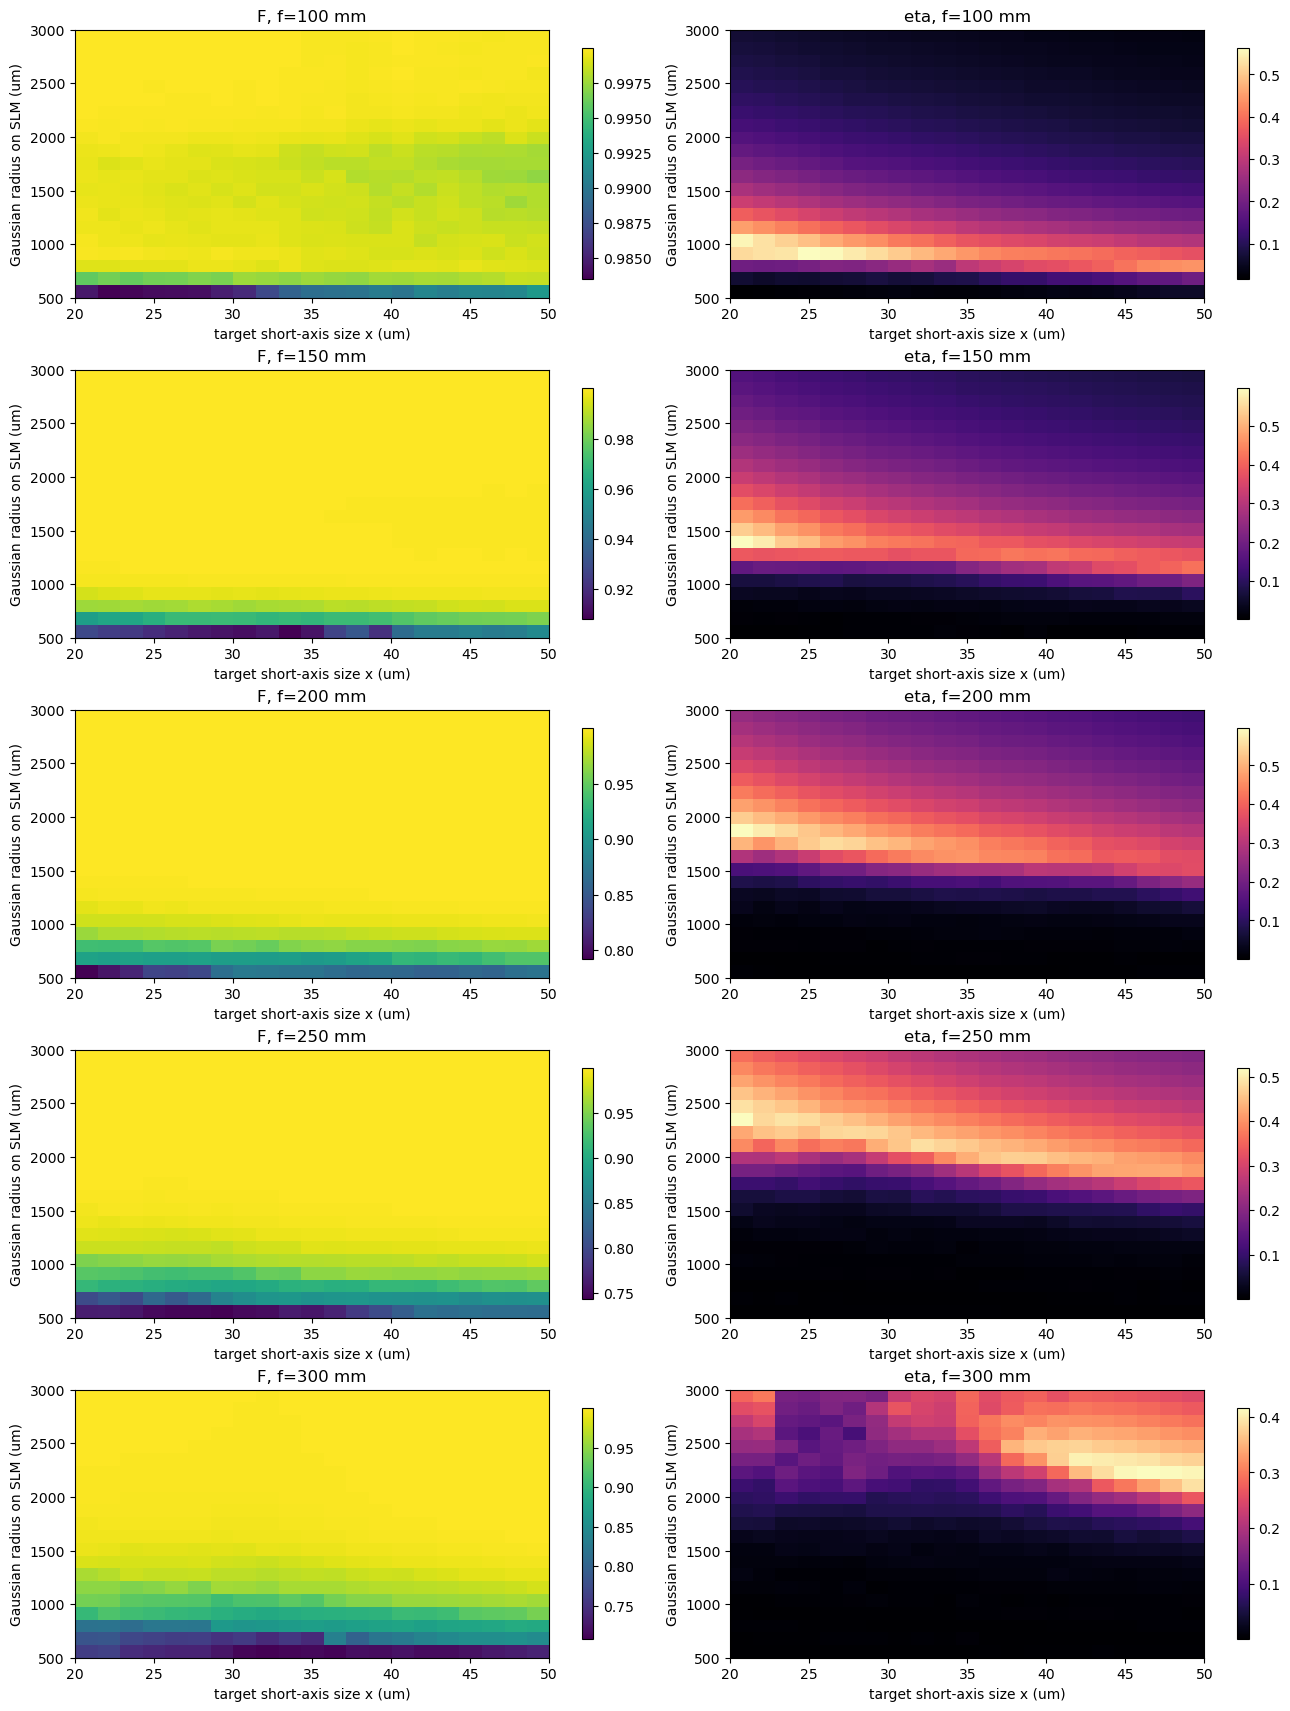

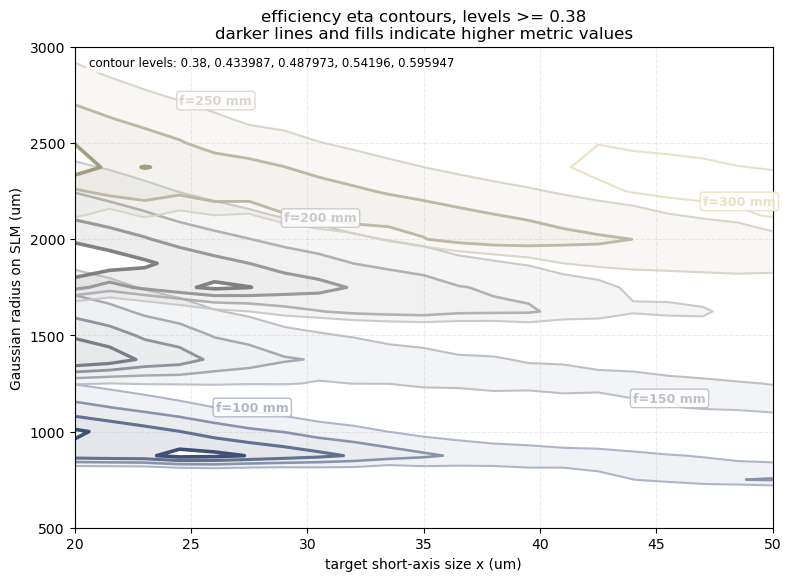

In [10]:
ideal_gaussian_contour_level: float = 0.38
ideal_gaussian_contour_count: int = 5
ideal_gaussian_contour_fill_alpha: float = 0.16
ideal_gaussian_contour_line_alpha: float = 0.92

required_names = ("ideal_gaussian_fidelity_grid", "ideal_gaussian_efficiency_grid")
missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise RuntimeError(f"Run the ideal Gaussian radius-size-focal scan first. Missing variables: {missing_names}.")
if ideal_gaussian_contour_metric not in ("fidelity", "efficiency"):
    raise ValueError(f"ideal_gaussian_contour_metric must be 'fidelity' or 'efficiency', got {ideal_gaussian_contour_metric!r}.")
if ideal_gaussian_contour_count < 1:
    raise ValueError(f"ideal_gaussian_contour_count must be at least 1, got {ideal_gaussian_contour_count}.")

short_axis_axis = np.asarray(scan_ideal_gaussian_short_axis_um_values, dtype=float)
radius_axis = np.asarray(scan_ideal_gaussian_radius_um_values, dtype=float)
focal_axis = np.asarray(scan_ideal_gaussian_focal_length_mm_values, dtype=float)
heatmap_extent = [
    float(np.min(short_axis_axis)),
    float(np.max(short_axis_axis)),
    float(np.min(radius_axis)),
    float(np.max(radius_axis)),
]

fig, axes = plt.subplots(
    len(focal_axis),
    2,
    figsize=(12.8, max(3.4 * len(focal_axis), 4.8)),
    constrained_layout=True,
    squeeze=False,
)
for focal_index, focal_length_value in enumerate(focal_axis):
    fidelity_image = axes[focal_index, 0].imshow(
        ideal_gaussian_fidelity_grid[focal_index],
        origin="lower",
        aspect="auto",
        extent=heatmap_extent,
        cmap="viridis",
    )
    axes[focal_index, 0].set_title(f"F, f={focal_length_value:g} mm")
    axes[focal_index, 0].set_xlabel("target short-axis size x (um)")
    axes[focal_index, 0].set_ylabel("Gaussian radius on SLM (um)")
    fig.colorbar(fidelity_image, ax=axes[focal_index, 0], shrink=0.86)

    efficiency_image = axes[focal_index, 1].imshow(
        ideal_gaussian_efficiency_grid[focal_index],
        origin="lower",
        aspect="auto",
        extent=heatmap_extent,
        cmap="magma",
    )
    axes[focal_index, 1].set_title(f"eta, f={focal_length_value:g} mm")
    axes[focal_index, 1].set_xlabel("target short-axis size x (um)")
    axes[focal_index, 1].set_ylabel("Gaussian radius on SLM (um)")
    fig.colorbar(efficiency_image, ax=axes[focal_index, 1], shrink=0.86)
fig.savefig(scan_output_dir / "ideal_gaussian_radius_size_focal_heatmaps.png", dpi=220)
plt.show()


def _tint_color(color: tuple[float, float, float, float], tint: float) -> tuple[float, float, float, float]:
    rgba = np.asarray(mcolors.to_rgba(color), dtype=float)
    rgba[:3] = rgba[:3] * (1.0 - tint) + tint
    return tuple(rgba)


def _level_color(base_color: tuple[float, float, float, float], level_index: int, level_count: int) -> tuple[float, float, float, float]:
    if level_count <= 1:
        return tuple(mcolors.to_rgba(base_color, alpha=ideal_gaussian_contour_line_alpha))
    tint = 0.58 * (1.0 - float(level_index) / float(level_count - 1))
    color = _tint_color(base_color, tint)
    return tuple(mcolors.to_rgba(color, alpha=ideal_gaussian_contour_line_alpha))


def _label_lowest_contour(
    ax: plt.Axes,
    contour_set: object,
    label: str,
    color: tuple[float, float, float, float],
) -> None:
    lowest_segments = contour_set.allsegs[0]
    if len(lowest_segments) == 0:
        return
    segment = max(lowest_segments, key=lambda item: item.shape[0])
    if segment.shape[0] == 0:
        return
    anchor_index = int(np.clip(round(0.80 * (segment.shape[0] - 1)), 0, segment.shape[0] - 1))
    anchor_x = float(segment[anchor_index, 0])
    anchor_y = float(segment[anchor_index, 1])
    ax.text(
        anchor_x,
        anchor_y,
        label,
        color=color,
        fontsize=9,
        fontweight="bold",
        ha="left",
        va="center",
        bbox={"facecolor": "white", "edgecolor": color, "boxstyle": "round,pad=0.22", "alpha": 0.86},
    )


metric_grid = ideal_gaussian_fidelity_grid if ideal_gaussian_contour_metric == "fidelity" else ideal_gaussian_efficiency_grid
metric_label = "coherent fidelity F" if ideal_gaussian_contour_metric == "fidelity" else "efficiency eta"
finite_metric_values = metric_grid[np.isfinite(metric_grid)]
if finite_metric_values.size == 0:
    raise RuntimeError("Cannot draw contours because the selected metric grid contains only NaN values.")
metric_max = float(np.nanmax(finite_metric_values))
if ideal_gaussian_contour_level > metric_max:
    raise ValueError(
        f"ideal_gaussian_contour_level={ideal_gaussian_contour_level:g} is above the global maximum {metric_max:g}."
    )
contour_levels = np.linspace(float(ideal_gaussian_contour_level), metric_max, int(ideal_gaussian_contour_count))
contour_levels = np.unique(np.round(contour_levels, decimals=10))
size_grid, radius_grid = np.meshgrid(short_axis_axis, radius_axis, indexing="xy")
base_color_map = plt.get_cmap("cividis")
base_color_positions = np.linspace(0.18, 0.78, len(focal_axis))

fig, ax = plt.subplots(1, 1, figsize=(7.8, 5.7), constrained_layout=True)
for focal_index, focal_length_value in enumerate(focal_axis):
    grid = metric_grid[focal_index]
    finite_grid = grid[np.isfinite(grid)]
    if finite_grid.size == 0:
        print(f"Skipping contours for f={focal_length_value:g} mm because all values are NaN.")
        continue
    local_min = float(np.nanmin(grid))
    local_max = float(np.nanmax(grid))
    local_levels = contour_levels[(contour_levels >= local_min) & (contour_levels <= local_max)]
    if local_levels.size == 0:
        print(
            f"Skipping contours for f={focal_length_value:g} mm because no levels are inside "
            f"[{local_min:g}, {local_max:g}]."
        )
        continue

    base_color = base_color_map(float(base_color_positions[focal_index]))
    fill_colors = [_level_color(base_color, level_index, max(local_levels.size, 2)) for level_index in range(local_levels.size)]
    line_colors = [_level_color(base_color, level_index, max(local_levels.size, 2)) for level_index in range(local_levels.size)]
    if local_levels.size >= 2:
        ax.contourf(
            size_grid,
            radius_grid,
            grid,
            levels=local_levels,
            colors=fill_colors,
            alpha=ideal_gaussian_contour_fill_alpha,
            antialiased=True,
        )
    contour_set = ax.contour(
        size_grid,
        radius_grid,
        grid,
        levels=local_levels,
        colors=line_colors,
        linewidths=np.linspace(1.5, 2.6, local_levels.size),
        alpha=ideal_gaussian_contour_line_alpha,
    )
    _label_lowest_contour(ax, contour_set, f"f={focal_length_value:g} mm", line_colors[0])

ax.set_title(
    f"{metric_label} contours, levels >= {ideal_gaussian_contour_level:g}\n"
    "darker lines and fills indicate higher metric values"
)
ax.set_xlabel("target short-axis size x (um)")
ax.set_ylabel("Gaussian radius on SLM (um)")
ax.set_xlim(float(np.min(short_axis_axis)), float(np.max(short_axis_axis)))
ax.set_ylim(float(np.min(radius_axis)), float(np.max(radius_axis)))
ax.grid(True, alpha=0.24, linestyle="--")
ax.text(
    0.02,
    0.98,
    "contour levels: " + ", ".join(f"{level:g}" for level in contour_levels),
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=8.5,
    bbox={"facecolor": "white", "edgecolor": "none", "boxstyle": "round,pad=0.25", "alpha": 0.78},
)
fig.savefig(scan_output_dir / "ideal_gaussian_radius_size_focal_contours.png", dpi=220)
plt.show()


In [7]:
required_names = ("ideal_gaussian_records", "ideal_gaussian_fidelity_grid", "ideal_gaussian_efficiency_grid")
missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise RuntimeError(f"Run the ideal Gaussian radius-size-focal scan first. Missing variables: {missing_names}.")

ideal_gaussian_scan_parameters = {
    "full_slm_shape": full_slm_shape,
    "superpixel_size": superpixel_size,
    "slm_shape": slm_shape,
    "half_slm_shape": half_slm_shape,
    "padding_factor": padding_factor,
    "half_camera_shape": half_camera_shape,
    "wavelength_nm": wavelength_nm,
    "slm_pixel_pitch_um": slm_pixel_pitch_um,
    "camera_pixel_pitch_um": camera_pixel_pitch_um,
    "base_focal_length_mm": ideal_gaussian_focal_length_mm,
    "base_psf_sigma_um": base_psf_sigma_um,
    "base_mask_radius_margin_um": base_mask_radius_margin_um,
    "base_linear_tilt": base_linear_tilt,
    "base_quadratic_curvature_x": base_quadratic_curvature_x,
    "base_quadratic_curvature_y": base_quadratic_curvature_y,
    "base_linear_angle_rad": base_linear_angle_rad,
    "base_conical_weight": base_conical_weight,
    "aspect_ratio_y_over_x": aspect_ratio_scan_y_over_x,
    "scan_ideal_gaussian_focal_length_mm_values": tuple(float(value) for value in scan_ideal_gaussian_focal_length_mm_values),
    "scan_ideal_gaussian_radius_um_values": tuple(float(value) for value in scan_ideal_gaussian_radius_um_values),
    "scan_ideal_gaussian_short_axis_um_values": tuple(float(value) for value in scan_ideal_gaussian_short_axis_um_values),
    "gaussian_radius_definition": "amplitude 1/e radius in the SLM plane, A = exp(-(x^2 + y^2) / r^2)",
    "scan_maxiter": scan_maxiter,
    "loss_scale": loss_scale,
    "optimize_phase": optimize_phase,
    "fidelity_definition": "F = abs(sum(conj(A_target*mask*exp(1j*target_phase)) * output_field * mask))**2 / (sum(abs(A_target*mask)**2) * sum(abs(output_field*mask)**2))",
    "contour_metric": ideal_gaussian_contour_metric,
    "contour_level": ideal_gaussian_contour_level,
    "contour_count": ideal_gaussian_contour_count,
    "contour_fill_alpha": ideal_gaussian_contour_fill_alpha,
    "contour_line_alpha": ideal_gaussian_contour_line_alpha,
}

ideal_gaussian_scan_payload = {
    "parameters": ideal_gaussian_scan_parameters,
    "records": list(ideal_gaussian_records),
    "focal_length_mm_axis": np.asarray(scan_ideal_gaussian_focal_length_mm_values, dtype=float),
    "gaussian_radius_um_axis": np.asarray(scan_ideal_gaussian_radius_um_values, dtype=float),
    "short_axis_um_axis": np.asarray(scan_ideal_gaussian_short_axis_um_values, dtype=float),
    "fidelity_grid": np.asarray(ideal_gaussian_fidelity_grid, dtype=float),
    "efficiency_grid": np.asarray(ideal_gaussian_efficiency_grid, dtype=float),
    "grid_axis_order": "focal_length_mm, gaussian_radius_um, short_axis_um",
    "heatmap_extent": np.asarray(
        [
            min(scan_ideal_gaussian_short_axis_um_values),
            max(scan_ideal_gaussian_short_axis_um_values),
            min(scan_ideal_gaussian_radius_um_values),
            max(scan_ideal_gaussian_radius_um_values),
        ],
        dtype=float,
    ),
}

ideal_gaussian_scan_payload_path = scan_output_dir / "ideal_gaussian_radius_size_focal_scan_payload.npy"
np.save(ideal_gaussian_scan_payload_path, ideal_gaussian_scan_payload, allow_pickle=True)

print("Saved complete ideal Gaussian radius-size-focal scan payload:")
print(ideal_gaussian_scan_payload_path)
print("Load with:")
print("payload = np.load(ideal_gaussian_scan_payload_path, allow_pickle=True).item()")


Saved complete ideal Gaussian radius-size-focal scan payload:
tophat_scan_outputs/ideal_gaussian_radius_size_focal_scan_payload.npy
Load with:
payload = np.load(ideal_gaussian_scan_payload_path, allow_pickle=True).item()


## 8. Scan Objective Function Forms


In [ ]:
loss_form_records: list[dict[str, Any]] = []
loss_form_histories: list[npt.NDArray[np.float64]] = []

fig, ax = plt.subplots(1, 1, figsize=(7.2, 4.8), constrained_layout=True)
for loss_form in loss_form_names:
    label = f"loss-form scan {loss_form_labels[loss_form]}"
    print(f"Running {label}")
    try:
        optimizer = build_scan_optimizer(
            base_target_width_x_um,
            base_target_height_y_um,
            base_psf_sigma_um,
            base_mask_radius_margin_um,
            base_linear_tilt,
            base_astigmatism_weight,
            base_quadratic_curvature,
            base_linear_angle_rad,
            base_conical_weight,
        )
        fidelity_history, scipy_result = optimize_with_loss_form_history(
            optimizer,
            scan_maxiter,
            loss_form_scan_scale,
            optimize_phase,
            loss_form,
        )
        history = np.asarray(fidelity_history, dtype=float)
        record = {
            "loss_form": loss_form,
            "loss_label": loss_form_labels[loss_form],
            "loss_scale": loss_form_scan_scale,
            "loss_evaluations": len(history),
            "accepted_iterations": len(optimizer.iteration_loss_history),
            "final_cost_overlap_fidelity": history[-1] if len(history) > 0 else np.nan,
            "success": bool(scipy_result.success),
            "message": str(scipy_result.message),
        }
        if history.size > 0:
            y_values = np.maximum(1.0 - history, np.finfo(float).eps)
            ax.plot(np.arange(1, len(y_values) + 1), y_values, lw=2.0, label=loss_form_labels[loss_form])
    except Exception as error:
        print_scan_failure(label, error)
        history = np.asarray([], dtype=float)
        record = failed_scan_record(
            {
                "loss_form": loss_form,
                "loss_label": loss_form_labels[loss_form],
                "loss_scale": loss_form_scan_scale,
                "final_cost_overlap_fidelity": np.nan,
            },
            error,
        )
    loss_form_histories.append(history)
    loss_form_records.append(record)

with (scan_output_dir / "loss_form_scan_summary.csv").open("w", encoding="utf-8") as file:
    file.write("loss_form,loss_label,loss_scale,loss_evaluations,accepted_iterations,final_cost_overlap_fidelity,success,message\n")
    for record in loss_form_records:
        file.write(
            f"{record['loss_form']},{record['loss_label']},{record['loss_scale']},"
            f"{record['loss_evaluations']},{record['accepted_iterations']},"
            f"{record['final_cost_overlap_fidelity']},{record['success']},{record['message']}\n"
        )

loss_form_summary_array = np.asarray(
    [
        [
            index,
            record["loss_scale"],
            record["loss_evaluations"],
            record["accepted_iterations"],
            record["final_cost_overlap_fidelity"],
            float(record["success"]),
        ]
        for index, record in enumerate(loss_form_records)
    ],
    dtype=float,
)
save_curve_arrays(
    "loss_form_scan",
    tuple(record["loss_label"] for record in loss_form_records),
    loss_form_histories,
    loss_form_summary_array,
)

ax.set_xlabel("objective / loss evaluation")
ax.set_ylabel("1 - cost-overlap fidelity")
ax.set_yscale("log")
ax.set_title("Effect of objective function form")
ax.grid(True, alpha=0.25, linestyle="--")
ax.legend(frameon=True, fontsize=8)
fig.savefig(scan_output_dir / "loss_form_scan_fidelity_vs_iteration.png", dpi=220)
plt.show()


Running loss-form scan: 1 - M


In [8]:
required_names = ("loss_form_records", "loss_form_histories")
missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise RuntimeError(f"Run the loss-form scan first. Missing variables: {missing_names}.")

loss_form_scan_parameters = {
    "full_slm_shape": full_slm_shape,
    "superpixel_size": superpixel_size,
    "slm_shape": slm_shape,
    "half_slm_shape": half_slm_shape,
    "padding_factor": padding_factor,
    "half_camera_shape": half_camera_shape,
    "wavelength_nm": wavelength_nm,
    "calibration_h5_path": calibration_h5_path,
    "half_side": half_side,
    "slm_pixel_pitch_um": slm_pixel_pitch_um,
    "camera_pixel_pitch_um": camera_pixel_pitch_um,
    "focal_length_mm": focal_length_mm,
    "base_target_width_x_um": base_target_width_x_um,
    "base_target_height_y_um": base_target_height_y_um,
    "base_psf_sigma_um": base_psf_sigma_um,
    "base_mask_radius_margin_um": base_mask_radius_margin_um,
    "base_linear_tilt": base_linear_tilt,
    "base_astigmatism_weight": base_astigmatism_weight,
    "base_quadratic_curvature": base_quadratic_curvature,
    "base_linear_angle_rad": base_linear_angle_rad,
    "base_conical_weight": base_conical_weight,
    "scan_maxiter": scan_maxiter,
    "loss_form_scan_scale": loss_form_scan_scale,
    "loss_form_names": tuple(loss_form_names),
    "loss_form_labels": dict(loss_form_labels),
    "optimize_phase": optimize_phase,
    "fidelity_definition": "F = abs(sum(conj(A_target*mask*exp(1j*target_phase)) * output_field * mask))**2 / (sum(abs(A_target*mask)**2) * sum(abs(output_field*mask)**2))",
    "x_axis": "objective / loss evaluation",
}

loss_form_summary_fields = (
    "loss_form_index",
    "loss_scale",
    "loss_evaluations",
    "accepted_iterations",
    "final_cost_overlap_fidelity",
    "success",
)
loss_form_summary = np.asarray(
    [
        [
            index,
            record["loss_scale"],
            record["loss_evaluations"],
            record["accepted_iterations"],
            record["final_cost_overlap_fidelity"],
            float(record["success"]),
        ]
        for index, record in enumerate(loss_form_records)
    ],
    dtype=float,
)

loss_form_curve_names = np.asarray([record["loss_label"] for record in loss_form_records], dtype=object)
loss_form_history_lengths = np.asarray([len(history) for history in loss_form_histories], dtype=int)
loss_form_max_history_length = int(np.max(loss_form_history_lengths))
loss_form_fidelity = np.full((len(loss_form_histories), loss_form_max_history_length), np.nan, dtype=float)
for history_index, history in enumerate(loss_form_histories):
    history_array = np.asarray(history, dtype=float)
    loss_form_fidelity[history_index, : history_array.size] = history_array

loss_form_scan_payload = {
    "parameters": loss_form_scan_parameters,
    "records": list(loss_form_records),
    "summary_fields": loss_form_summary_fields,
    "summary": loss_form_summary,
    "curve_names": loss_form_curve_names,
    "history_lengths": loss_form_history_lengths,
    "evaluation_index": np.arange(loss_form_max_history_length, dtype=int),
    "fidelity": loss_form_fidelity,
    "one_minus_fidelity": 1.0 - loss_form_fidelity,
    "raw_fidelity_histories": np.asarray(
        [np.asarray(history, dtype=float) for history in loss_form_histories],
        dtype=object,
    ),
}

loss_form_scan_payload_path = scan_output_dir / "loss_form_scan_payload.npy"
np.save(loss_form_scan_payload_path, loss_form_scan_payload, allow_pickle=True)

print("Saved complete loss-form scan payload:")
print(loss_form_scan_payload_path)
print("Load with:")
print("payload = np.load(loss_form_scan_payload_path, allow_pickle=True).item()")


Saved complete loss-form scan payload:
tophat_scan_outputs/loss_form_scan_payload.npy
Load with:
payload = np.load(loss_form_scan_payload_path, allow_pickle=True).item()


## 9. R-sigma Scan: Fidelity and Efficiency Heatmaps


Running R-sigma scan: R=0.0008, sigma=20.0 um
Running R-sigma scan: R=0.0008, sigma=25.0 um
Running R-sigma scan: R=0.0008, sigma=30.0 um
Running R-sigma scan: R=0.0008, sigma=35.0 um
Running R-sigma scan: R=0.0008, sigma=40.0 um
Running R-sigma scan: R=0.0008, sigma=45.0 um
Running R-sigma scan: R=0.0008, sigma=50.0 um
Running R-sigma scan: R=0.0024, sigma=20.0 um
Running R-sigma scan: R=0.0024, sigma=25.0 um
Running R-sigma scan: R=0.0024, sigma=30.0 um
Running R-sigma scan: R=0.0024, sigma=35.0 um
Running R-sigma scan: R=0.0024, sigma=40.0 um
Running R-sigma scan: R=0.0024, sigma=45.0 um
Running R-sigma scan: R=0.0024, sigma=50.0 um
Running R-sigma scan: R=0.004, sigma=20.0 um
Running R-sigma scan: R=0.004, sigma=25.0 um
Running R-sigma scan: R=0.004, sigma=30.0 um
Running R-sigma scan: R=0.004, sigma=35.0 um
Running R-sigma scan: R=0.004, sigma=40.0 um
Running R-sigma scan: R=0.004, sigma=45.0 um
Running R-sigma scan: R=0.004, sigma=50.0 um
Running R-sigma scan: R=0.0056, sigma=20.

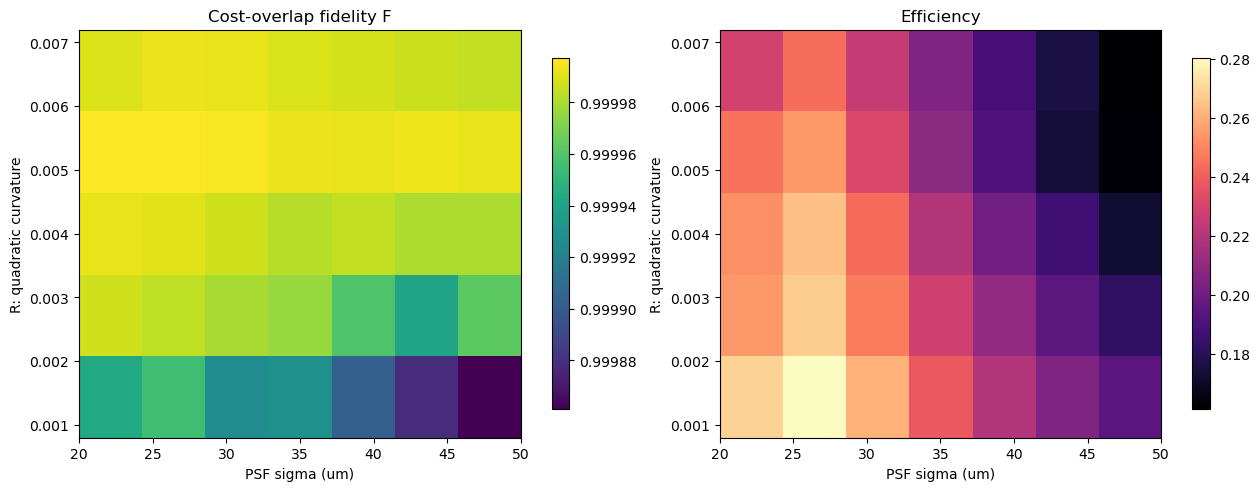

In [12]:
rsigma_records: list[dict[str, Any]] = []
fidelity_grid = np.full((len(scan_quadratic_curvature_values), len(scan_psf_sigma_um_values)), np.nan, dtype=float)
efficiency_grid = np.full_like(fidelity_grid, np.nan)

for r_index, quadratic_curvature in enumerate(scan_quadratic_curvature_values):
    for sigma_index, psf_sigma_um in enumerate(scan_psf_sigma_um_values):
        label = f"R-sigma scan R={quadratic_curvature}, sigma={psf_sigma_um} um"
        print(f"Running {label}")
        try:
            record = run_scan_case(
                base_target_width_x_um,
                base_target_height_y_um,
                psf_sigma_um,
                base_mask_radius_margin_um,
                base_linear_tilt,
                base_astigmatism_weight,
                quadratic_curvature,
                base_linear_angle_rad,
                base_conical_weight,
                scan_maxiter,
                False,
            )
        except Exception as error:
            print_scan_failure(label, error)
            record = failed_scan_record(
                {
                    "width_x_um": base_target_width_x_um,
                    "height_y_um": base_target_height_y_um,
                    "psf_sigma_um": psf_sigma_um,
                    "mask_radius_margin_um": base_mask_radius_margin_um,
                    "linear_tilt": base_linear_tilt,
                    "astigmatism_weight": base_astigmatism_weight,
                    "quadratic_curvature": quadratic_curvature,
                    "linear_angle_rad": base_linear_angle_rad,
                    "conical_weight": base_conical_weight,
                },
                error,
            )
        rsigma_records.append(record)
        fidelity_grid[r_index, sigma_index] = record["cost_overlap_fidelity"]
        efficiency_grid[r_index, sigma_index] = record["efficiency"]

save_scan_table(scan_output_dir / "r_sigma_scan_summary.csv", rsigma_records)
np.save(scan_output_dir / "r_sigma_fidelity_grid.npy", fidelity_grid)
np.save(scan_output_dir / "r_sigma_efficiency_grid.npy", efficiency_grid)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), constrained_layout=True)
extent = [
    min(scan_psf_sigma_um_values),
    max(scan_psf_sigma_um_values),
    min(scan_quadratic_curvature_values),
    max(scan_quadratic_curvature_values),
]
image_fidelity = axes[0].imshow(fidelity_grid, origin="lower", aspect="auto", extent=extent, cmap="viridis")
axes[0].set_title("Cost-overlap fidelity F")
axes[0].set_xlabel("PSF sigma (um)")
axes[0].set_ylabel("R: quadratic curvature")
fig.colorbar(image_fidelity, ax=axes[0], shrink=0.86)
image_efficiency = axes[1].imshow(efficiency_grid, origin="lower", aspect="auto", extent=extent, cmap="magma")
axes[1].set_title("Efficiency")
axes[1].set_xlabel("PSF sigma (um)")
axes[1].set_ylabel("R: quadratic curvature")
fig.colorbar(image_efficiency, ax=axes[1], shrink=0.86)
fig.savefig(scan_output_dir / "r_sigma_heatmaps.png", dpi=220)
plt.show()


In [13]:
required_names = ("rsigma_records", "fidelity_grid", "efficiency_grid")
missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise RuntimeError(f"Run the R-sigma scan first. Missing variables: {missing_names}.")

r_sigma_scan_parameters = {
    "full_slm_shape": full_slm_shape,
    "superpixel_size": superpixel_size,
    "slm_shape": slm_shape,
    "half_slm_shape": half_slm_shape,
    "padding_factor": padding_factor,
    "half_camera_shape": half_camera_shape,
    "wavelength_nm": wavelength_nm,
    "calibration_h5_path": calibration_h5_path,
    "half_side": half_side,
    "slm_pixel_pitch_um": slm_pixel_pitch_um,
    "camera_pixel_pitch_um": camera_pixel_pitch_um,
    "focal_length_mm": focal_length_mm,
    "base_target_width_x_um": base_target_width_x_um,
    "base_target_height_y_um": base_target_height_y_um,
    "base_mask_radius_margin_um": base_mask_radius_margin_um,
    "base_linear_tilt": base_linear_tilt,
    "base_astigmatism_weight": base_astigmatism_weight,
    "base_linear_angle_rad": base_linear_angle_rad,
    "base_conical_weight": base_conical_weight,
    "scan_maxiter": scan_maxiter,
    "loss_scale": loss_scale,
    "optimize_phase": optimize_phase,
    "scan_quadratic_curvature_values": tuple(float(value) for value in scan_quadratic_curvature_values),
    "scan_psf_sigma_um_values": tuple(float(value) for value in scan_psf_sigma_um_values),
}

r_sigma_scan_payload = {
    "parameters": r_sigma_scan_parameters,
    "records": list(rsigma_records),
    "quadratic_curvature_axis": np.asarray(scan_quadratic_curvature_values, dtype=float),
    "psf_sigma_um_axis": np.asarray(scan_psf_sigma_um_values, dtype=float),
    "fidelity_grid": np.asarray(fidelity_grid, dtype=float),
    "efficiency_grid": np.asarray(efficiency_grid, dtype=float),
    "heatmap_extent": np.asarray(
        [
            min(scan_psf_sigma_um_values),
            max(scan_psf_sigma_um_values),
            min(scan_quadratic_curvature_values),
            max(scan_quadratic_curvature_values),
        ],
        dtype=float,
    ),
    "fidelity_definition": "F = cost-overlap fidelity after optimization",
    "efficiency_definition": "farfield efficiency returned by run_scan_case",
}

r_sigma_scan_payload_path = scan_output_dir / "r_sigma_scan_payload.npy"
np.save(r_sigma_scan_payload_path, r_sigma_scan_payload, allow_pickle=True)

print("Saved complete R-sigma scan payload:")
print(r_sigma_scan_payload_path)
print("Load with:")
print("payload = np.load(r_sigma_scan_payload_path, allow_pickle=True).item()")


Saved complete R-sigma scan payload:
tophat_scan_outputs/r_sigma_scan_payload.npy
Load with:
payload = np.load(r_sigma_scan_payload_path, allow_pickle=True).item()


## 10. Broad Multi-Parameter Scan: Fidelity vs Efficiency


In [ ]:
wide_scan_records: list[dict[str, Any]] = []

for width_x_um, height_y_um in wide_target_sizes_um:
    for psf_sigma_um in wide_psf_sigma_um_values:
        for quadratic_curvature in wide_quadratic_curvature_values:
            for linear_tilt in wide_linear_tilt_values:
                for conical_weight in wide_conical_weight_values:
                    label = (
                        "wide scan "
                        f"size=({width_x_um}, {height_y_um}) um, "
                        f"sigma={psf_sigma_um} um, R={quadratic_curvature}, "
                        f"linear_tilt={linear_tilt}, B={conical_weight}"
                    )
                    print(f"Running {label}")
                    try:
                        record = run_scan_case(
                            width_x_um,
                            height_y_um,
                            psf_sigma_um,
                            base_mask_radius_margin_um,
                            linear_tilt,
                            base_astigmatism_weight,
                            quadratic_curvature,
                            base_linear_angle_rad,
                            conical_weight,
                            scan_maxiter,
                            False,
                        )
                    except Exception as error:
                        print_scan_failure(label, error)
                        record = failed_scan_record(
                            {
                                "width_x_um": width_x_um,
                                "height_y_um": height_y_um,
                                "psf_sigma_um": psf_sigma_um,
                                "mask_radius_margin_um": base_mask_radius_margin_um,
                                "linear_tilt": linear_tilt,
                                "astigmatism_weight": base_astigmatism_weight,
                                "quadratic_curvature": quadratic_curvature,
                                "linear_angle_rad": base_linear_angle_rad,
                                "conical_weight": conical_weight,
                            },
                            error,
                        )
                    wide_scan_records.append(record)

save_scan_table(scan_output_dir / "wide_scan_summary.csv", wide_scan_records)

fidelity_values = np.asarray([record["cost_overlap_fidelity"] for record in wide_scan_records], dtype=float)
efficiency_values = np.asarray([record["efficiency"] for record in wide_scan_records], dtype=float)
sigma_values = np.asarray([record["psf_sigma_um"] for record in wide_scan_records], dtype=float)
curvature_values = np.asarray([record["quadratic_curvature"] for record in wide_scan_records], dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), constrained_layout=True)
scatter_sigma = axes[0].scatter(fidelity_values, efficiency_values, c=sigma_values, cmap="viridis", s=60, alpha=0.82, edgecolor="black", linewidth=0.35)
axes[0].set_title("Colored by PSF sigma")
axes[0].set_xlabel("cost-overlap fidelity F")
axes[0].set_ylabel("efficiency")
axes[0].grid(True, alpha=0.25, linestyle="--")
fig.colorbar(scatter_sigma, ax=axes[0], label="sigma (um)")
scatter_curvature = axes[1].scatter(fidelity_values, efficiency_values, c=curvature_values, cmap="plasma", s=60, alpha=0.82, edgecolor="black", linewidth=0.35)
axes[1].set_title("Colored by R")
axes[1].set_xlabel("cost-overlap fidelity F")
axes[1].set_ylabel("efficiency")
axes[1].grid(True, alpha=0.25, linestyle="--")
fig.colorbar(scatter_curvature, ax=axes[1], label="R")
fig.savefig(scan_output_dir / "wide_scan_fidelity_efficiency_scatter.png", dpi=220)
plt.show()

best_fidelity_index: int | None = None
best_efficiency_index: int | None = None
best_fidelity_record: dict[str, Any] | None = None
best_efficiency_record: dict[str, Any] | None = None
if np.any(np.isfinite(fidelity_values)):
    best_fidelity_index = int(np.nanargmax(fidelity_values))
    best_fidelity_record = dict(wide_scan_records[best_fidelity_index])
    print("Best fidelity record:", best_fidelity_record)
else:
    print("No finite fidelity values were produced in the wide scan.")
if np.any(np.isfinite(efficiency_values)):
    best_efficiency_index = int(np.nanargmax(efficiency_values))
    best_efficiency_record = dict(wide_scan_records[best_efficiency_index])
    print("Best efficiency record:", best_efficiency_record)
else:
    print("No finite efficiency values were produced in the wide scan.")
print(f"Saved scan outputs to: {scan_output_dir.resolve()}")


Running wide scan: size=(30.0, 180.0) um, sigma=10.0 um, R=0.0012, linear_tilt=-0.04, B=0.0
Running wide scan: size=(30.0, 180.0) um, sigma=10.0 um, R=0.0012, linear_tilt=0.0, B=0.0
Running wide scan: size=(30.0, 180.0) um, sigma=10.0 um, R=0.0012, linear_tilt=0.04, B=0.0
Running wide scan: size=(30.0, 180.0) um, sigma=10.0 um, R=0.00172, linear_tilt=-0.04, B=0.0
Running wide scan: size=(30.0, 180.0) um, sigma=10.0 um, R=0.00172, linear_tilt=0.0, B=0.0
Running wide scan: size=(30.0, 180.0) um, sigma=10.0 um, R=0.00172, linear_tilt=0.04, B=0.0


In [ ]:
required_names = ("wide_scan_records", "fidelity_values", "efficiency_values", "sigma_values", "curvature_values")
missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise RuntimeError(f"Run the wide scan first. Missing variables: {missing_names}.")

wide_scan_parameters = {
    "full_slm_shape": full_slm_shape,
    "superpixel_size": superpixel_size,
    "slm_shape": slm_shape,
    "half_slm_shape": half_slm_shape,
    "padding_factor": padding_factor,
    "half_camera_shape": half_camera_shape,
    "wavelength_nm": wavelength_nm,
    "calibration_h5_path": calibration_h5_path,
    "half_side": half_side,
    "slm_pixel_pitch_um": slm_pixel_pitch_um,
    "camera_pixel_pitch_um": camera_pixel_pitch_um,
    "focal_length_mm": focal_length_mm,
    "base_mask_radius_margin_um": base_mask_radius_margin_um,
    "base_astigmatism_weight": base_astigmatism_weight,
    "base_linear_angle_rad": base_linear_angle_rad,
    "scan_maxiter": scan_maxiter,
    "loss_scale": loss_scale,
    "optimize_phase": optimize_phase,
    "wide_target_sizes_um": tuple(tuple(float(item) for item in size) for size in wide_target_sizes_um),
    "wide_psf_sigma_um_values": tuple(float(value) for value in wide_psf_sigma_um_values),
    "wide_quadratic_curvature_values": tuple(float(value) for value in wide_quadratic_curvature_values),
    "wide_linear_tilt_values": tuple(float(value) for value in wide_linear_tilt_values),
    "wide_conical_weight_values": tuple(float(value) for value in wide_conical_weight_values),
}

wide_scan_payload = {
    "parameters": wide_scan_parameters,
    "records": list(wide_scan_records),
    "fidelity": np.asarray(fidelity_values, dtype=float),
    "efficiency": np.asarray(efficiency_values, dtype=float),
    "psf_sigma_um": np.asarray(sigma_values, dtype=float),
    "quadratic_curvature": np.asarray(curvature_values, dtype=float),
    "best_fidelity_index": best_fidelity_index,
    "best_efficiency_index": best_efficiency_index,
    "best_fidelity_record": best_fidelity_record,
    "best_efficiency_record": best_efficiency_record,
    "plot_x": "cost-overlap fidelity F",
    "plot_y": "efficiency",
}

wide_scan_payload_path = scan_output_dir / "wide_scan_payload.npy"
np.save(wide_scan_payload_path, wide_scan_payload, allow_pickle=True)

print("Saved complete wide scan payload:")
print(wide_scan_payload_path)
print("Load with:")
print("payload = np.load(wide_scan_payload_path, allow_pickle=True).item()")
